# PPO Search Analysis v3: Joint and Split Recurrent-Layer Study

This notebook analyzes the finished Optuna search stored in `ppo_agent_search_v3.db`, with special attention to the fact that the search space now mixes **two recurrent-layer families**: **LSTM** and **GRU**.

The notebook is organized around four questions:

1. How did the full search behave overall?
2. How do the **GRU** and **LSTM** subspaces behave when analyzed **together** and **separately**?
3. What do the **training curves** suggest about reward, entropy, and pruning behavior?
4. Which directions look promising for the next search iteration?

## Data Sources

- **Optuna SQLite study**: trial-level parameters, objective values, states, and intermediate pruning values
- **Weights & Biases runs**: training curves and final multi-demand evaluation metrics

## Why this split matters

Because the study jointly searched over recurrent layer type and architecture/hyperparameters, a combined leaderboard is not enough. If GRU and LSTM prefer **different architectural regimes**, the analysis should expose that explicitly instead of only reporting the best overall trial.

In [140]:
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from optuna.importance import get_param_importances
from optuna.samplers import TPESampler
from optuna.trial import TrialState, create_trial

warnings.filterwarnings('ignore')

# Shared publication style for all paper figures.
PAPER_COLORS = ['#2166ac', '#e08214', '#1b9e77', '#b2182b', '#756bb1', '#636363']
sns.set_theme(context='paper', style='whitegrid', palette=PAPER_COLORS)
plt.rcParams.update({
    'figure.figsize': (7.15, 4.0),
    'figure.dpi': 140,
    'savefig.dpi': 600,
    'font.size': 8.5,
    'axes.titlesize': 9.5,
    'axes.labelsize': 8.5,
    'axes.titleweight': 'regular',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.65,
    'lines.markersize': 4.0,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'grid.color': '0.88',
    'grid.linewidth': 0.55,
    'grid.alpha': 1.0,
    'legend.fontsize': 7.5,
    'legend.frameon': False,
    'legend.handlelength': 2.2,
})

DB_CANDIDATES = [
    Path('ppo_agent_search_v3.db'),
    Path('Code/ppo_agent_search_v3.db'),
]
DB_FILE = next((path for path in DB_CANDIDATES if path.exists()), None)
if DB_FILE is None:
    raise FileNotFoundError(f'Could not find the Optuna database. Checked: {DB_CANDIDATES}')

DB_PATH = f"sqlite:///{DB_FILE.as_posix()}"
STUDY_NAME = 'ppo_agent_search3'
TOPK = 12
TOP_FRACTION = 0.15
WANDB_ENTITY = 'jzapanag'          # edit if needed
WANDB_PROJECT = 'TrafficSignalControl-Expanded-v1'  # edit if needed
WANDB_TOP_PER_TYPE = 5


if Path('Code').exists():
    OUTPUT_ROOT = Path('Code/search_analysis_v3_outputs')
else:
    OUTPUT_ROOT = Path('search_analysis_v3_outputs')
FIG_DIR = OUTPUT_ROOT / 'figures'
CSV_DIR = OUTPUT_ROOT / 'csv'
FIG_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(filename, dpi=600):
    path = FIG_DIR / f"{filename}.png"
    plt.savefig(path, bbox_inches='tight', dpi=dpi)
    print(f'Saved figure: {path}')
    return path

study = optuna.load_study(study_name=STUDY_NAME, storage=DB_PATH)
df = study.trials_dataframe(attrs=('number', 'value', 'state', 'params', 'user_attrs', 'system_attrs', 'datetime_start', 'datetime_complete'))
df['duration_h'] = (pd.to_datetime(df['datetime_complete']) - pd.to_datetime(df['datetime_start'])).dt.total_seconds() / 3600
completed = df[df['state'] == 'COMPLETE'].copy()
param_cols = [c for c in df.columns if c.startswith('params_')]
num_param_cols = [c for c in param_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_param_cols = [c for c in param_cols if c not in num_param_cols]

if 'params_recurrent_type' not in df.columns:
    raise ValueError('This study does not expose params_recurrent_type; check that the v3 database is the recurrent-layer search.')

print('Study:', study.study_name)
print('Direction:', study.directions[0].name)
print('Trials:', len(df))
print('Completed:', len(completed))
print('Best value:', study.best_value)
print('Best trial:', study.best_trial.number)
print('Recurrent types:', sorted(df['params_recurrent_type'].dropna().unique().tolist()))

Study: ppo_agent_search3
Direction: MAXIMIZE
Trials: 450
Completed: 217
Best value: -4.474982487726353
Best trial: 261
Recurrent types: ['gru', 'lstm']


## Interpretation Notes and External Guidance

A few analysis choices below follow standard guidance from reputable RL / Optuna references:

- **Optuna TPE**: the current search uses multivariate/grouped TPE, which is explicitly designed to model joint parameter structure rather than sampling each variable independently. That matters here because `recurrent_type`, convolution depth, recurrent size, and PPO hyperparameters may interact. See the Optuna TPESampler docs: <https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html>
- **RL evaluation**: Stable-Baselines3 recommends using a separate test environment and averaging over multiple evaluation episodes, and also notes that training reward curves are only a proxy for true evaluation performance. This is consistent with using W&B training curves for diagnostics while keeping final conclusions tied to the multi-demand evaluation. See: <https://stable-baselines3.readthedocs.io/en/v2.7.0/guide/rl_tips.html>
- **Entropy as an exploration signal**: policy entropy is a practical indicator of how random / exploratory the policy remains during training. OpenAI Spinning Up discusses entropy in the exploration-exploitation tradeoff. See: <https://spinningup.openai.com/en/latest/algorithms/sac.html>

These references do not replace the task-specific conclusions of this notebook, but they help justify why reward, entropy, pruning curves, and separate held-out evaluation should all be analyzed together.

## 1. Search-Level Summary

These views answer whether the search ran cleanly, how budget was allocated across recurrent types, and whether one family was pruned or completed disproportionately.

,n_trials,n_complete,n_pruned,n_fail,best_value,median_completed_value,mean_duration_h
0,450,217,233,0,-4.474982,-5.991038,0.663278


state,COMPLETE,PRUNED
params_recurrent_type,,
gru,171,182
lstm,46,51


,count,mean,median,max
params_recurrent_type,,,,
lstm,46,-8.270418,-5.960682,-4.474982
gru,171,-9.594816,-5.994290,-4.558593


Saved figure: Code\search_analysis_v3_outputs\figures\01_search_state_summary.png


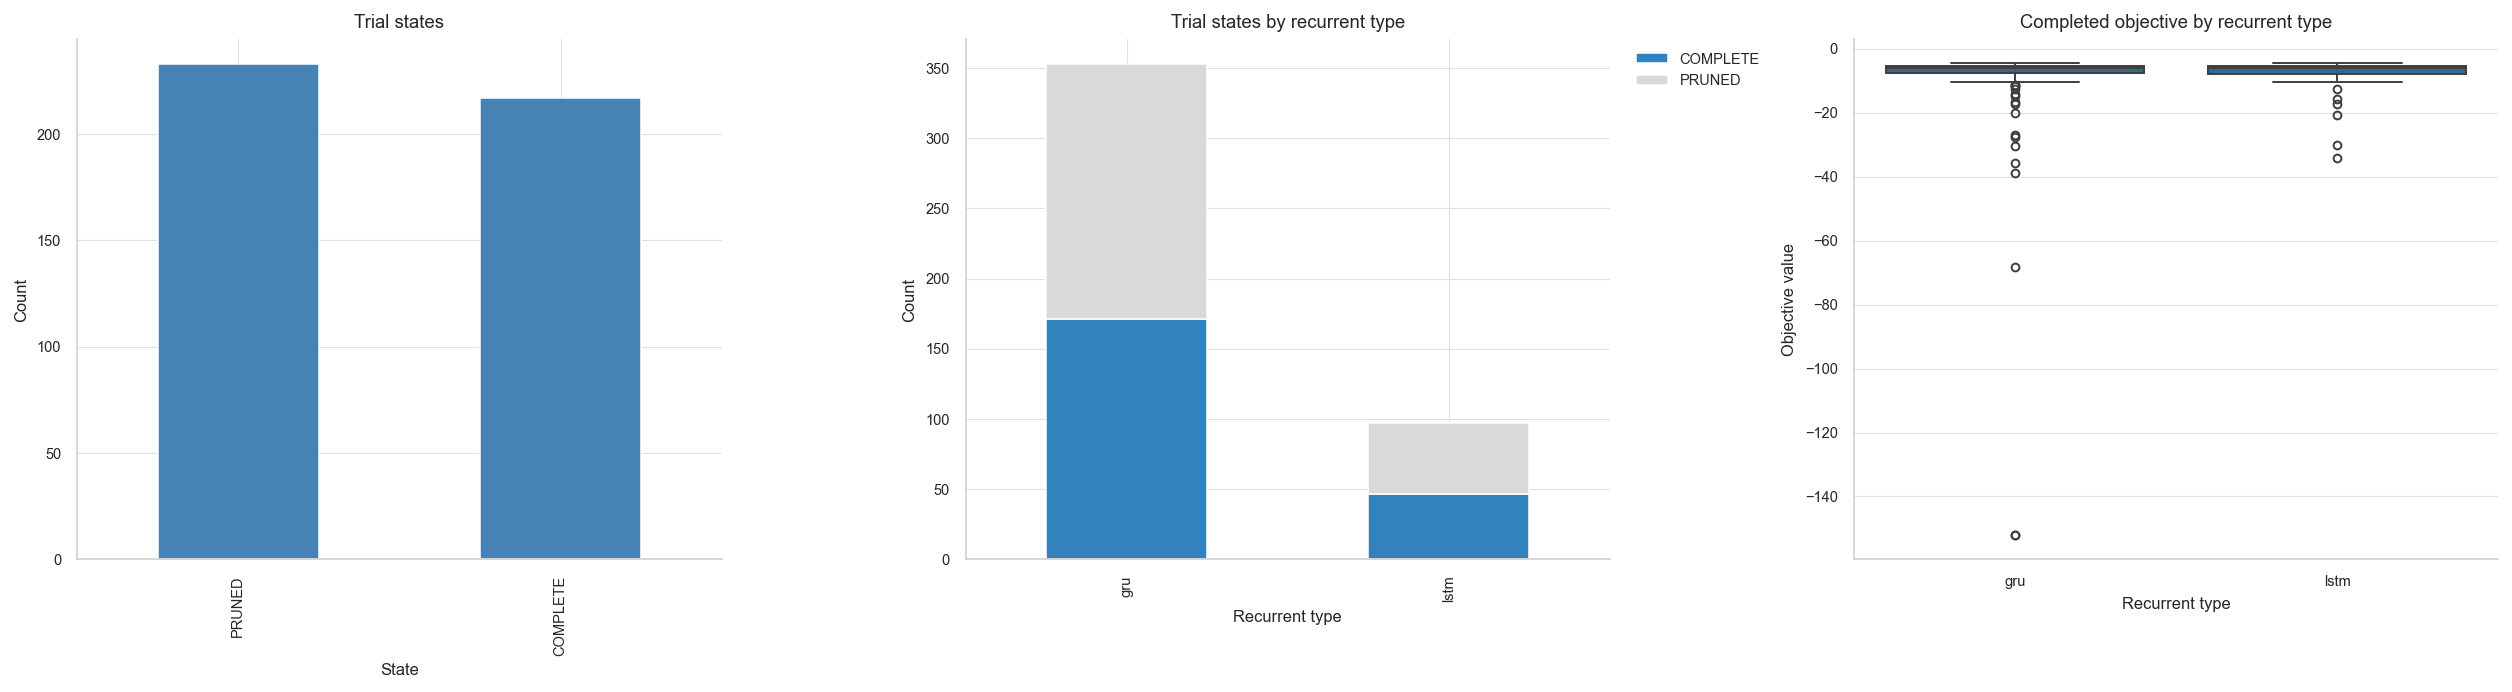

In [141]:
summary = pd.DataFrame({
    'n_trials': [len(df)],
    'n_complete': [(df['state'] == 'COMPLETE').sum()],
    'n_pruned': [(df['state'] == 'PRUNED').sum()],
    'n_fail': [(df['state'] == 'FAIL').sum()],
    'best_value': [study.best_value],
    'median_completed_value': [completed['value'].median()],
    'mean_duration_h': [completed['duration_h'].mean()],
})
display(summary)

state_by_type = pd.crosstab(df['params_recurrent_type'], df['state']).sort_index()
display(state_by_type)

completed_stats_by_type = completed.groupby('params_recurrent_type')['value'].agg(['count', 'mean', 'median', 'max']).sort_values('max', ascending=False)
display(completed_stats_by_type)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['state'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Trial states')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Count')

state_by_type.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20c')
axes[1].set_title('Trial states by recurrent type')
axes[1].set_xlabel('Recurrent type')
axes[1].set_ylabel('Count')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

sns.boxplot(data=completed, x='params_recurrent_type', y='value', ax=axes[2])
axes[2].set_title('Completed objective by recurrent type')
axes[2].set_xlabel('Recurrent type')
axes[2].set_ylabel('Objective value')

plt.tight_layout()
save_fig('01_search_state_summary')
plt.show()

Saved figure: Code\search_analysis_v3_outputs\figures\02_optimization_history_overall_and_by_recurrent_type.png


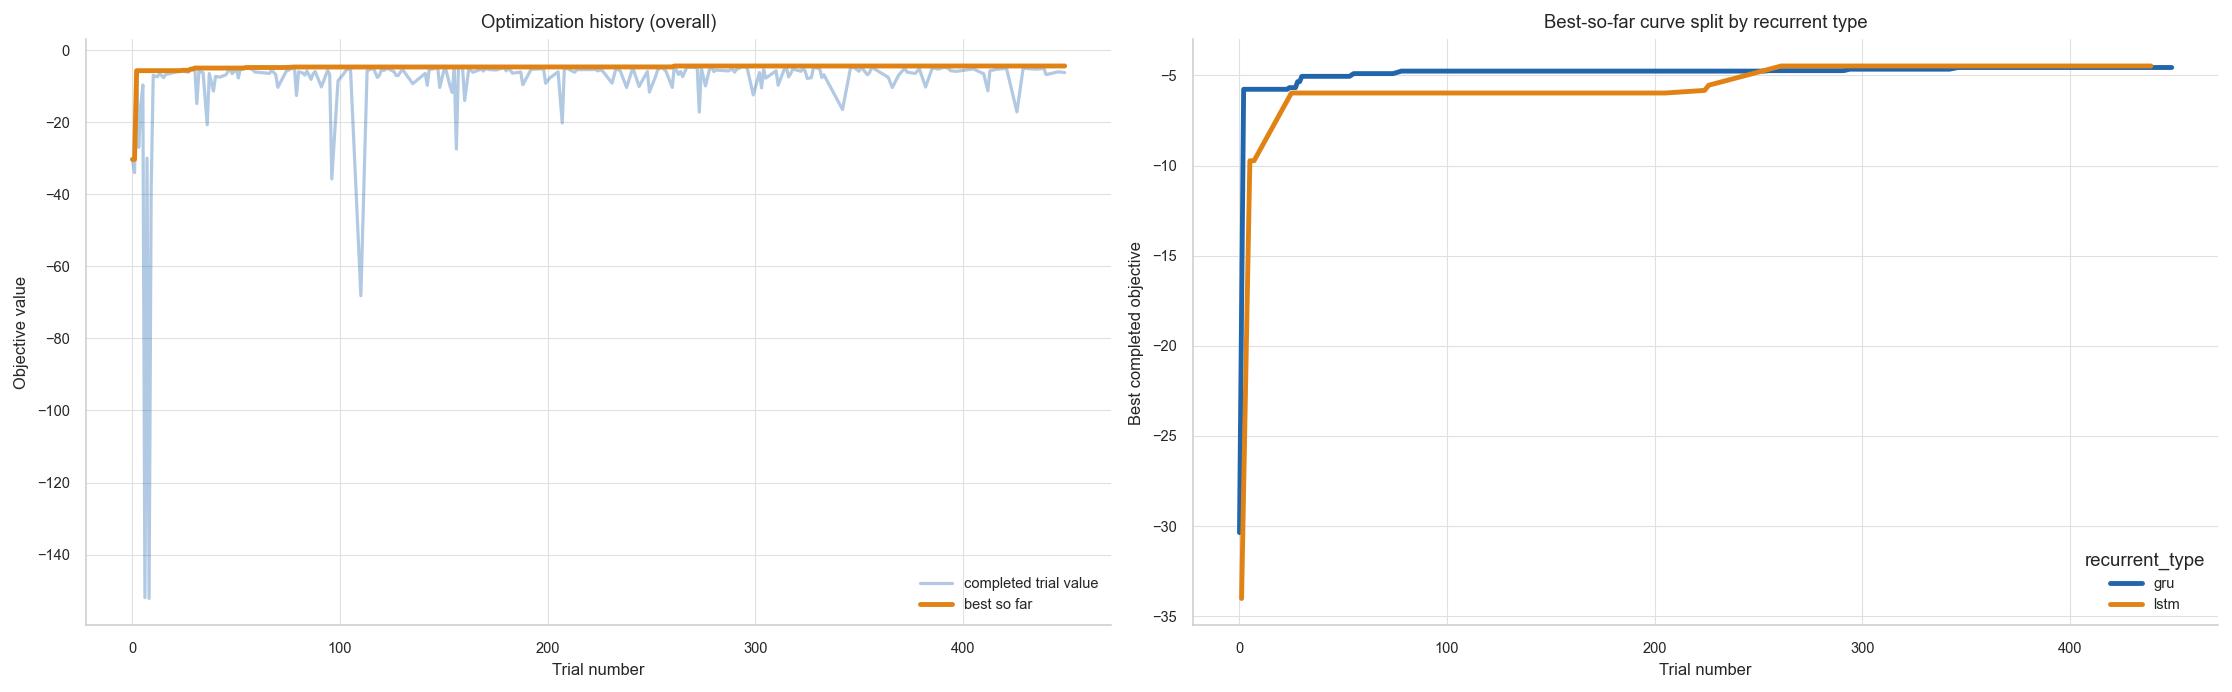

Saved figure: Code\search_analysis_v3_outputs\figures\03_trial_duration_vs_objective.png


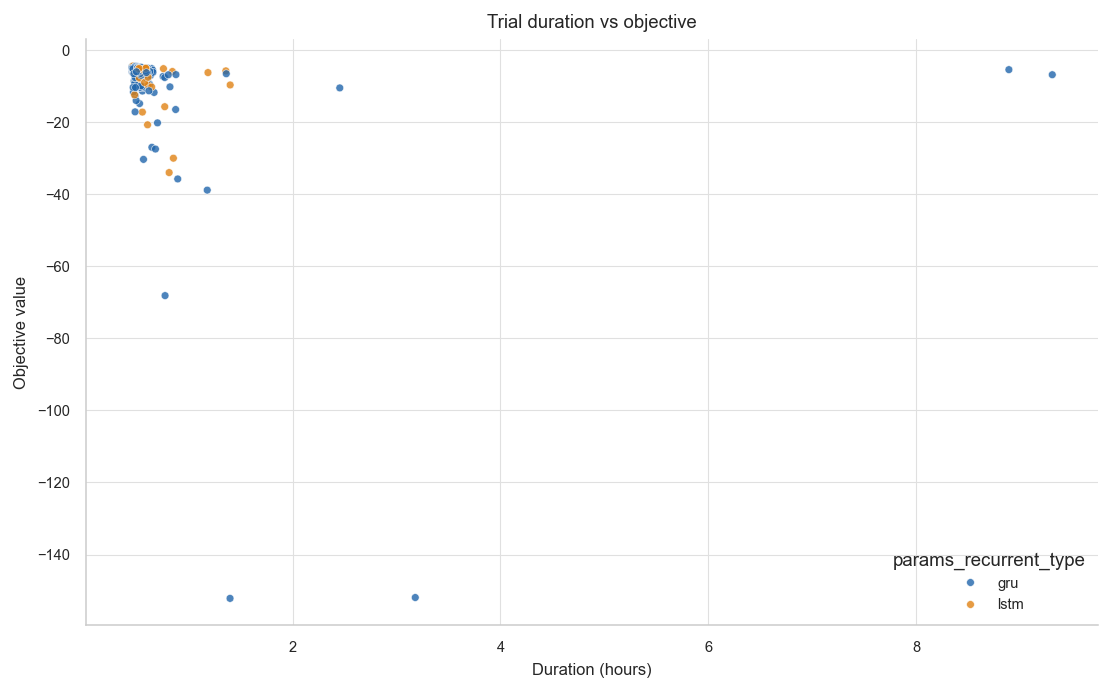

In [142]:
best_so_far = completed.sort_values('number').copy()
best_so_far['best_overall_so_far'] = best_so_far['value'].cummax()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(best_so_far['number'], best_so_far['value'], alpha=0.35, label='completed trial value')
axes[0].plot(best_so_far['number'], best_so_far['best_overall_so_far'], linewidth=2.5, label='best so far')
axes[0].set_title('Optimization history (overall)')
axes[0].set_xlabel('Trial number')
axes[0].set_ylabel('Objective value')
axes[0].legend()

for rtype, sub in completed.sort_values('number').groupby('params_recurrent_type'):
    sub = sub.copy()
    sub['best_so_far'] = sub['value'].cummax()
    axes[1].plot(sub['number'], sub['best_so_far'], linewidth=2.5, label=rtype)
axes[1].set_title('Best-so-far curve split by recurrent type')
axes[1].set_xlabel('Trial number')
axes[1].set_ylabel('Best completed objective')
axes[1].legend(title='recurrent_type')

plt.tight_layout()
save_fig('02_optimization_history_overall_and_by_recurrent_type')
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=completed, x='duration_h', y='value', hue='params_recurrent_type', alpha=0.8)
plt.title('Trial duration vs objective')
plt.xlabel('Duration (hours)')
plt.ylabel('Objective value')
plt.tight_layout()
save_fig('03_trial_duration_vs_objective')
plt.show()

## 2. Combined and Split Hyperparameter Effects

The search is joint, but the analysis should be both **combined** and **conditional on recurrent type**. The goal is to see whether the best architecture is globally dominant or whether GRU and LSTM occupy different good regions.

In [143]:
def clone_subset_study(base_study, recurrent_type=None):
    subset = []
    for tr in base_study.trials:
        if tr.state != TrialState.COMPLETE:
            continue
        if recurrent_type is not None and tr.params.get('recurrent_type') != recurrent_type:
            continue
        if tr.value is None:
            continue
        subset.append(create_trial(
            params=tr.params,
            distributions=tr.distributions,
            value=tr.value,
            user_attrs=tr.user_attrs,
            system_attrs=tr.system_attrs,
            intermediate_values=tr.intermediate_values,
            state=TrialState.COMPLETE,
        ))
    direction = base_study.directions[0].name.lower()
    cloned = optuna.create_study(direction=direction, sampler=TPESampler(seed=42))
    for tr in subset:
        cloned.add_trial(tr)
    return cloned

importance_frames = []
for label, rtype in [('overall', None), ('gru', 'gru'), ('lstm', 'lstm')]:
    substudy = clone_subset_study(study, rtype)
    if len(substudy.trials) < 8:
        print(f'Skipping importance plot for {label}: only {len(substudy.trials)} completed trials.')
        continue
    imps = get_param_importances(substudy)
    imp_df = pd.DataFrame({'parameter': list(imps.keys()), 'importance': list(imps.values()), 'subset': label})
    importance_frames.append(imp_df)


[I 2026-08-29 15:49:47,874] A new study created in memory with name: no-name-1989b936-7f6f-4696-a501-cc88e14211f0
[I 2026-08-29 15:49:55,302] A new study created in memory with name: no-name-9ebb2fd2-0d14-41a9-8a88-eef070af400d
[I 2026-08-29 15:50:00,901] A new study created in memory with name: no-name-6bc2cab9-6b8a-47b5-91ed-9e381086877d


,parameter,importance,subset
0,learning_rate,0.759628,overall
1,entropy_coef,0.093897,overall
2,K_epochs,0.090956,overall
3,kernel_size_0,0.019499,overall
4,clip_range,0.009542,overall
5,gamma,0.009156,overall
6,optimizer,0.005220,overall
7,lambd,0.004241,overall
8,L2-reg,0.002171,overall
9,num_conv_layers,0.001745,overall


Saved figure: Code\search_analysis_v3_outputs\figures\04_param_importances_overall_gru_lstm.png


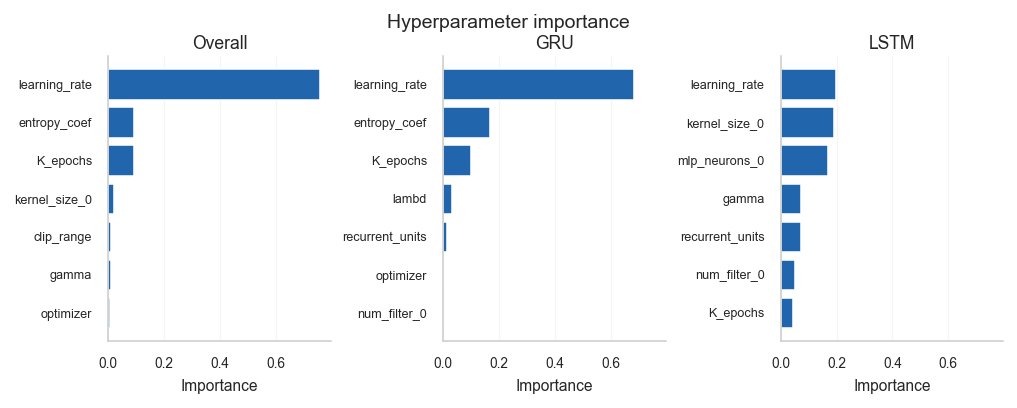

In [144]:
if not importance_frames:
    print('No subset had enough completed trials for importance estimation.')
else:
    importance_df = pd.concat(importance_frames, ignore_index=True)
    display(importance_df.groupby('subset').head(10))

    subsets = list(importance_df['subset'].unique())
    n_subsets = len(subsets)

    fig, axes = plt.subplots(
        1,
        n_subsets,
        figsize=(7.15, 2.65),  # compact IEEE two-column width
        sharex=True,
        constrained_layout=True,
    )

    if n_subsets == 1:
        axes = [axes]

    for ax, subset in zip(axes, subsets):
        sub = (
            importance_df[importance_df['subset'] == subset]
            .sort_values('importance', ascending=True)
            .tail(7)   # top 7 is more readable in one column
        )

        ax.barh(sub['parameter'], sub['importance'])

        title = subset.replace("overall", "Overall").replace("gru", "GRU").replace("lstm", "LSTM")
        ax.set_title(title, fontsize=9, pad=4)
        ax.set_xlabel('Importance', fontsize=8)
        ax.tick_params(axis='x', labelsize=7)
        ax.tick_params(axis='y', labelsize=6.5)
        ax.grid(True, axis='x', alpha=0.3)
        ax.grid(False, axis='y')

    fig.suptitle('Hyperparameter importance', fontsize=10, y=1.04)

    save_fig('04_param_importances_overall_gru_lstm')
    plt.show()

In [ ]:
# Compact manuscript replacement for the diagnostic importance figure.
IMPORTANCE_PARAMETER_NAMES = {
    'learning_rate': 'LR',
    'entropy_coef': 'Entropy',
    'K_epochs': 'PPO epochs',
    'kernel_size_0': 'Kernel',
    'kernels_size_0': 'Kernel',
    'recurrent_units': 'Recurrent units',
    'mlp_neurons_0': 'MLP units',
    'gamma': 'Gamma',
    'lambd': 'Lambda',
    'clip_range': 'Clip',
    'clip_rate': 'Clip',
    'num_filter_0': 'CNN filters',
    'num_filters_0': 'CNN filters',
    'stride_size_0': 'Stride',
    'strides_0': 'Stride',
    'l2_reg': 'L2 reg.',
    'L2-reg': 'L2 reg.',
    'weight_decay': 'Weight decay',
}

importance_rankings = {}
for subset in ['overall', 'gru', 'lstm']:
    ranked = (
        importance_df[importance_df['subset'] == subset]
        .sort_values('importance', ascending=False)
        .loc[lambda frame: frame['importance'] >= 0.0005]
        .head(5)
        .reset_index(drop=True)
    )
    importance_rankings[subset] = ranked

importance_table_rows = []
for rank_index in range(5):
    row = {'Rank': rank_index + 1}
    for subset, heading in [('overall', 'Overall'), ('gru', 'GRU'), ('lstm', 'LSTM')]:
        ranked = importance_rankings[subset]
        if rank_index < len(ranked):
            item = ranked.iloc[rank_index]
            concise_name = IMPORTANCE_PARAMETER_NAMES.get(
                item['parameter'], item['parameter'].replace('_', ' ')
            )
            row[heading] = f"{concise_name} ({item['importance']:.3f})"
        else:
            row[heading] = ''
    importance_table_rows.append(row)

importance_table_df = pd.DataFrame(importance_table_rows)
display(importance_table_df)

latex_body = [
    f"{row.Rank} & {row.Overall} & {row.GRU} & {row.LSTM} \\"
    for row in importance_table_df.itertuples(index=False)
]
latex_body = [line + '\\' for line in latex_body]
importance_table_latex = '\n'.join([
    r'\begin{table}[htbp]',
    r'\centering',
    r'\caption{Highest-ranked hyperparameters by estimated importance.}',
    r'\label{tab:param_importance}',
    r'\resizebox{\columnwidth}{!}{%',
    r'\begin{tabular}{c l l l}',
    r'\hline',
    r'\textbf{Rank} & \textbf{Overall} & \textbf{GRU} & \textbf{LSTM} \\',
    r'\hline',
    *latex_body,
    r'\hline',
    r'\end{tabular}%',
    r'}',
    r'\end{table}',
])
print(importance_table_latex)

TABLE_DIR = OUTPUT_ROOT / 'tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
importance_table_df.to_csv(CSV_DIR / '04_param_importance_top5_table.csv', index=False)
(TABLE_DIR / '04_param_importance_top5_table.tex').write_text(
    importance_table_latex, encoding='utf-8'
)

The compact table above is the manuscript replacement for Fig. 04. The original horizontal-bar figure is retained as a diagnostic notebook output. Rankings are computed independently within Overall, GRU, and LSTM from the existing Optuna importance estimates. Exports: [CSV](search_analysis_v3_outputs/csv/04_param_importance_top5_table.csv) and [LaTeX](search_analysis_v3_outputs/tables/04_param_importance_top5_table.tex).

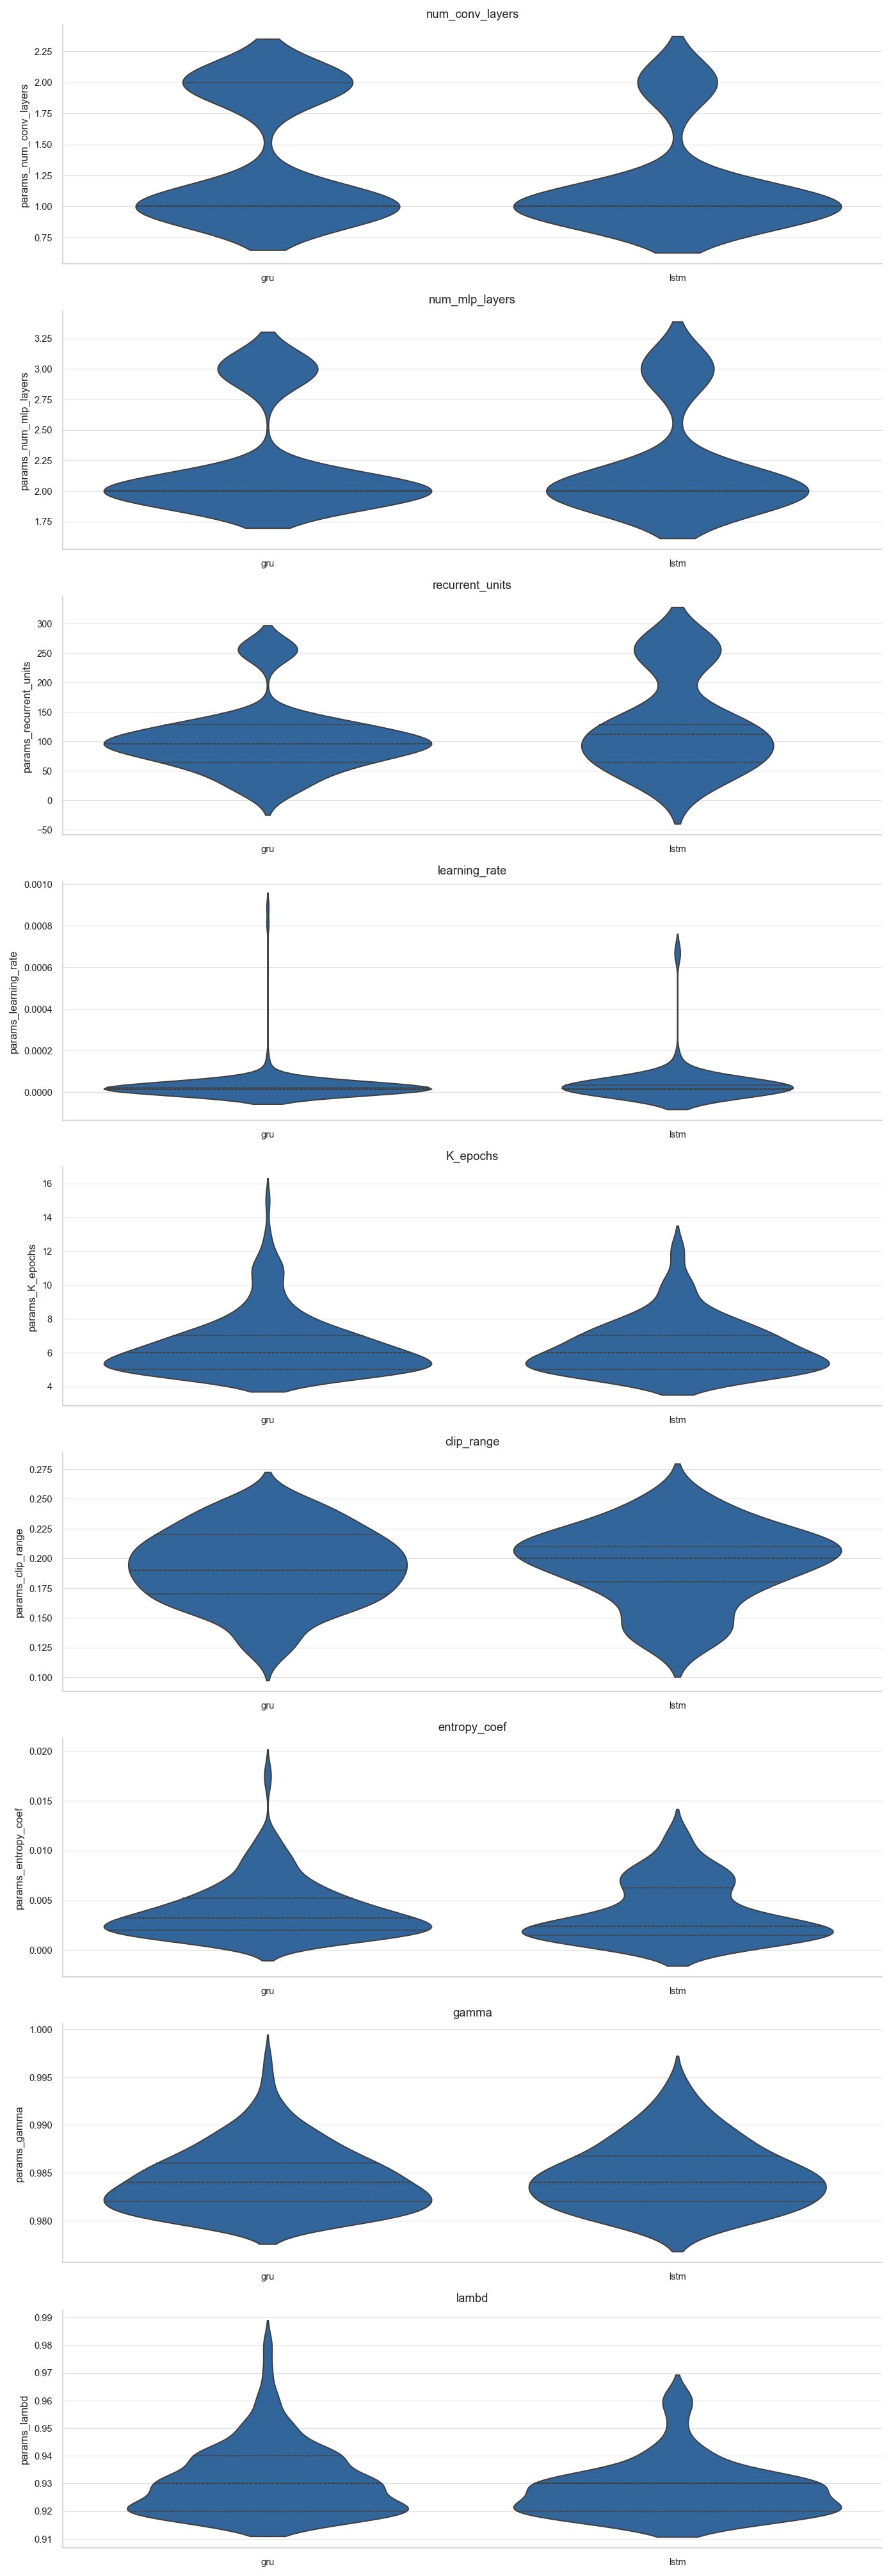

Saved figure: Code\search_analysis_v3_outputs\figures\06_completed_trial_frequency_num_conv_layers.png


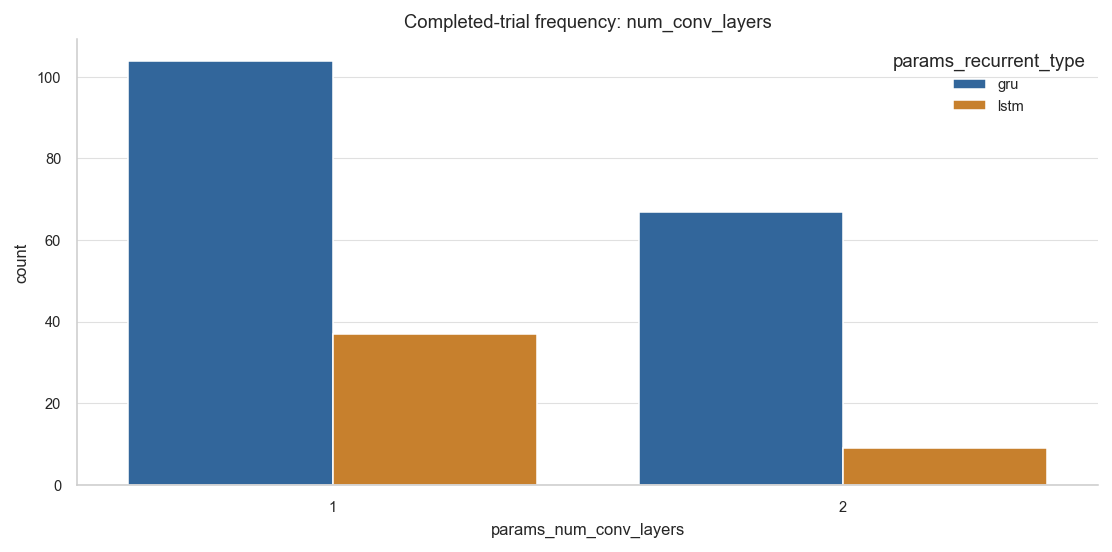

Saved figure: Code\search_analysis_v3_outputs\figures\06_completed_trial_frequency_num_mlp_layers.png


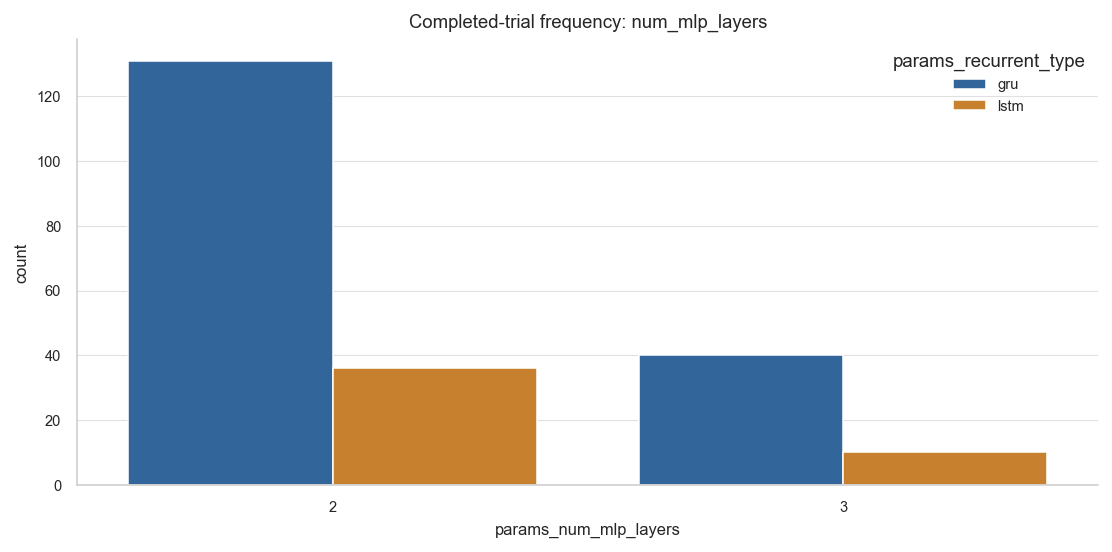

Saved figure: Code\search_analysis_v3_outputs\figures\06_completed_trial_frequency_optimizer.png


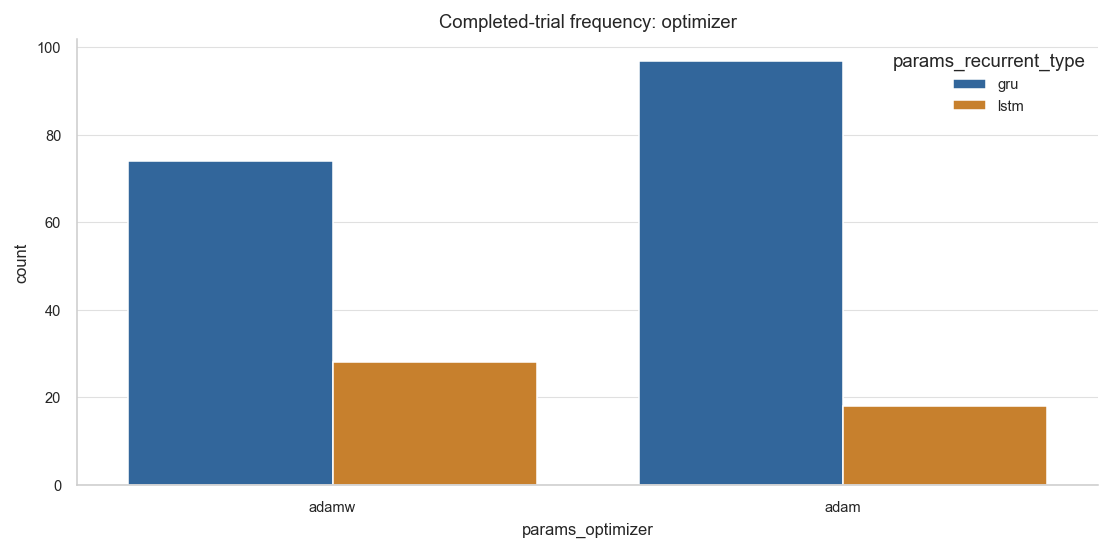

In [145]:
selected_numeric = [
    c for c in [
        'params_num_conv_layers', 'params_num_mlp_layers', 'params_recurrent_units',
        'params_learning_rate', 'params_K_epochs', 'params_clip_range',
        'params_entropy_coef', 'params_gamma', 'params_lambd'
    ] if c in completed.columns
]

fig, axes = plt.subplots(len(selected_numeric), 1, figsize=(10, max(4, 3.2 * len(selected_numeric))))
if len(selected_numeric) == 1:
    axes = [axes]
for ax, col in zip(axes, selected_numeric):
    sns.violinplot(data=completed, x='params_recurrent_type', y=col, ax=ax, inner='quartile')
    ax.set_title(col.replace('params_', ''))
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

selected_categorical = [c for c in ['params_num_conv_layers', 'params_num_mlp_layers', 'params_optimizer'] if c in completed.columns]
for col in selected_categorical:
    plt.figure(figsize=(8, 4))
    plot_df = completed[[col, 'params_recurrent_type']].dropna().copy()
    sns.countplot(data=plot_df, x=col, hue='params_recurrent_type')
    plt.title(f'Completed-trial frequency: {col.replace("params_", "")}')
    plt.tight_layout()
    save_fig(f"06_completed_trial_frequency_{col.replace('params_', '')}")
    plt.show()

In [146]:
top_cut = max(1, int(math.ceil(len(completed) * TOP_FRACTION)))
top_df = completed.sort_values('value', ascending=False).head(top_cut).copy()

display(top_df[['number', 'value', 'params_recurrent_type'] + [c for c in selected_numeric if c in top_df.columns]].head(TOPK))

for rtype in sorted(completed['params_recurrent_type'].dropna().unique()):
    sub = completed[completed['params_recurrent_type'] == rtype].sort_values('value', ascending=False).head(3).copy()
    cols = ['number', 'value', 'params_recurrent_type'] + [
        c for c in [
            'params_num_conv_layers', 'params_num_filter_0', 'params_num_filter_1',
            'params_kernel_size_0', 'params_kernel_size_1', 'params_stride_size_0', 'params_stride_size_1',
            'params_recurrent_units', 'params_num_mlp_layers', 'params_mlp_neurons_0', 'params_mlp_neurons_1',
            'params_learning_rate', 'params_K_epochs', 'params_clip_range', 'params_entropy_coef', 'params_optimizer'
        ] if c in sub.columns
    ]
    print(f'### Top 3 {rtype.upper()} trials')
    display(sub[cols].rename(columns=lambda x: x.replace('params_', '')))

,number,value,params_recurrent_type,params_num_conv_layers,params_num_mlp_layers,params_recurrent_units,params_learning_rate,params_K_epochs,params_clip_range,params_entropy_coef,params_gamma,params_lambd
261,261,-4.474982,lstm,1,2,128,0.000027,5,0.21,0.001754,0.986,0.92
346,346,-4.558593,gru,1,2,256,0.000027,5,0.19,0.001201,0.980,0.93
294,294,-4.652167,gru,1,2,256,0.000016,6,0.22,0.001707,0.983,0.92
255,255,-4.732659,gru,1,2,128,0.000015,5,0.19,0.002747,0.983,0.92
351,351,-4.738474,gru,1,2,256,0.000027,5,0.19,0.001503,0.980,0.94
78,78,-4.758847,gru,2,2,96,0.000014,6,0.20,0.008396,0.982,0.93
157,157,-4.764449,gru,2,2,96,0.000027,7,0.20,0.002370,0.986,0.93
356,356,-4.802472,gru,1,3,256,0.000012,6,0.20,0.005995,0.981,0.92
147,147,-4.803802,gru,2,2,96,0.000025,5,0.20,0.002864,0.986,0.92
315,315,-4.807939,gru,1,2,128,0.000010,6,0.18,0.005418,0.986,0.94


### Top 3 GRU trials


,number,value,recurrent_type,num_conv_layers,num_filter_0,num_filter_1,kernel_size_0,kernel_size_1,stride_size_0,stride_size_1,recurrent_units,num_mlp_layers,mlp_neurons_0,mlp_neurons_1,learning_rate,K_epochs,clip_range,entropy_coef,optimizer
346,346,-4.558593,gru,1,16,NaN,3,NaN,2,NaN,256,2,128,NaN,0.000027,5,0.19,0.001201,adamw
294,294,-4.652167,gru,1,16,NaN,3,NaN,2,NaN,256,2,128,NaN,0.000016,6,0.22,0.001707,adamw
255,255,-4.732659,gru,1,32,NaN,5,NaN,3,NaN,128,2,128,NaN,0.000015,5,0.19,0.002747,adamw


### Top 3 LSTM trials


,number,value,recurrent_type,num_conv_layers,num_filter_0,num_filter_1,kernel_size_0,kernel_size_1,stride_size_0,stride_size_1,recurrent_units,num_mlp_layers,mlp_neurons_0,mlp_neurons_1,learning_rate,K_epochs,clip_range,entropy_coef,optimizer
261,261,-4.474982,lstm,1,32,NaN,5,NaN,3,NaN,128,2,128,NaN,0.000027,5,0.21,0.001754,adamw
267,267,-4.830677,lstm,1,16,NaN,5,NaN,3,NaN,64,2,128,NaN,0.000015,6,0.17,0.004175,adamw
296,296,-4.858248,lstm,1,32,NaN,5,NaN,3,NaN,256,2,128,NaN,0.000031,5,0.23,0.001280,adamw


## 3. Updated Pruning Behavior

The pruning analysis should reflect the current protocol, not the old single-demand version.

### Current pruning logic

- pruning checks start after episode **400**
- pruning checks happen every **20** episodes
- each intermediate pruning score is a **weighted average** over demands **1000**, **1300**, and **1600**
- pruning uses a **separate seed block** from both training and final evaluation
- the final study objective is still the full multi-demand weighted evaluation

This section checks whether pruning behaved differently for GRU and LSTM, and whether one family was disproportionately removed before it could mature.

,trial_number,recurrent_type,state,step,intermediate_value
0,0,gru,COMPLETE,399,-16.288709
1,0,gru,COMPLETE,419,-25.156760
2,0,gru,COMPLETE,439,-24.872268
3,0,gru,COMPLETE,459,-32.231995
4,0,gru,COMPLETE,479,-38.541285


,params_recurrent_type,state,share
0,gru,PRUNED,0.515581
1,gru,COMPLETE,0.484419
2,lstm,PRUNED,0.525773
3,lstm,COMPLETE,0.474227


Saved figure: Code\search_analysis_v3_outputs\figures\07_pruning_trajectories_and_state_share.png


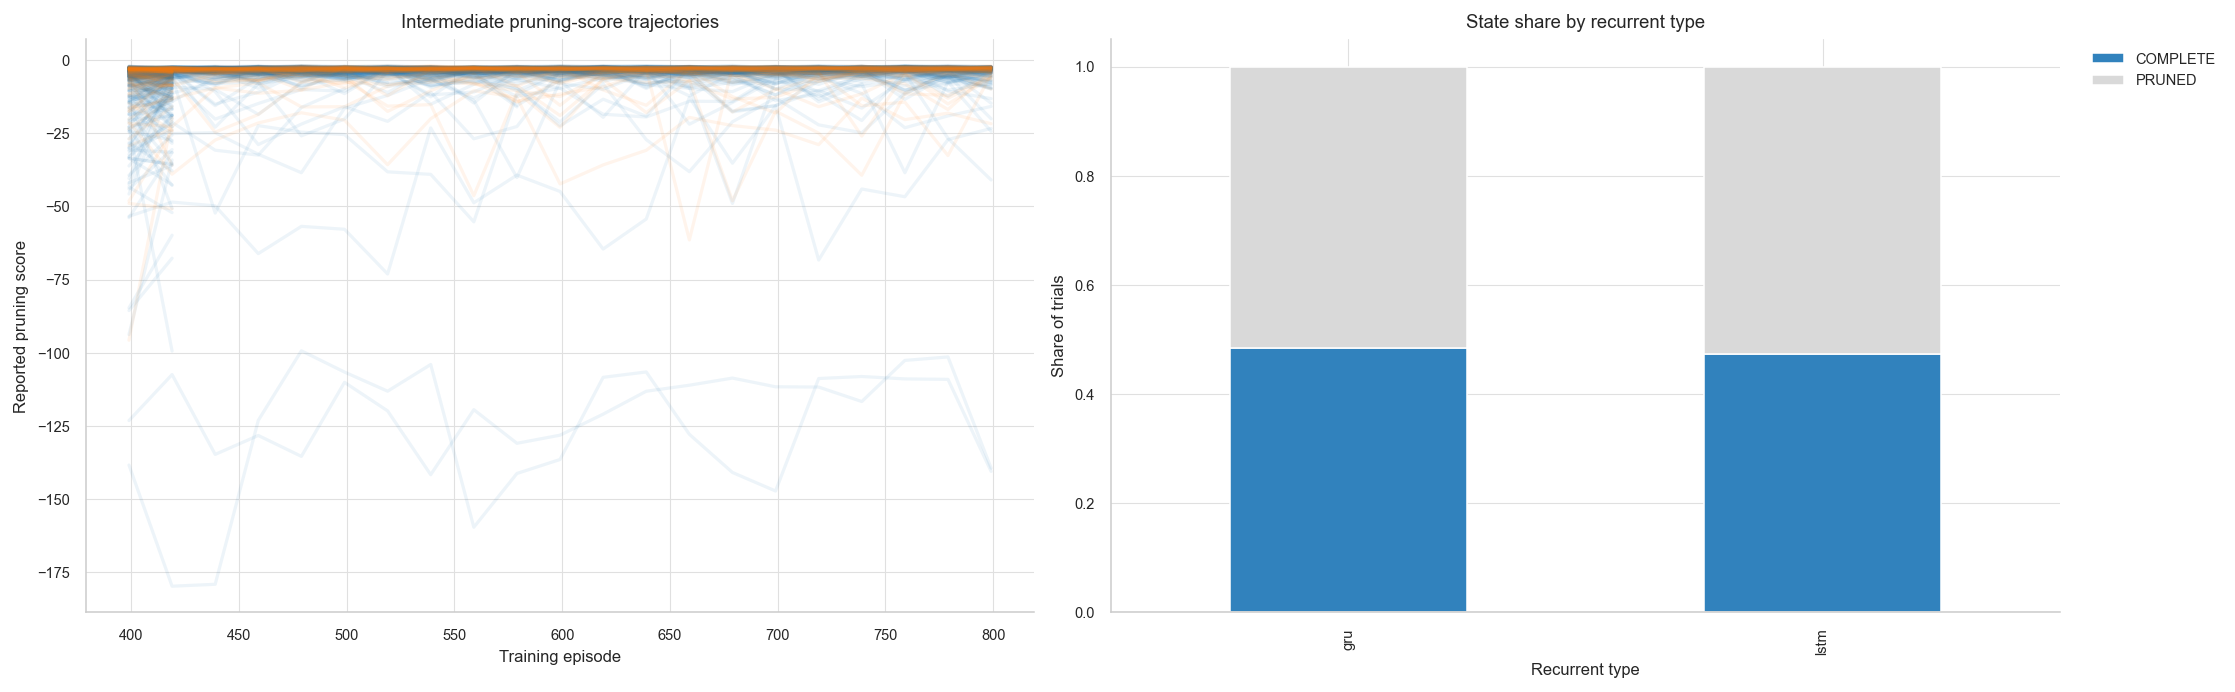

Saved figure: Code\search_analysis_v3_outputs\figures\07_pruning_trajectories_and_state_share.png


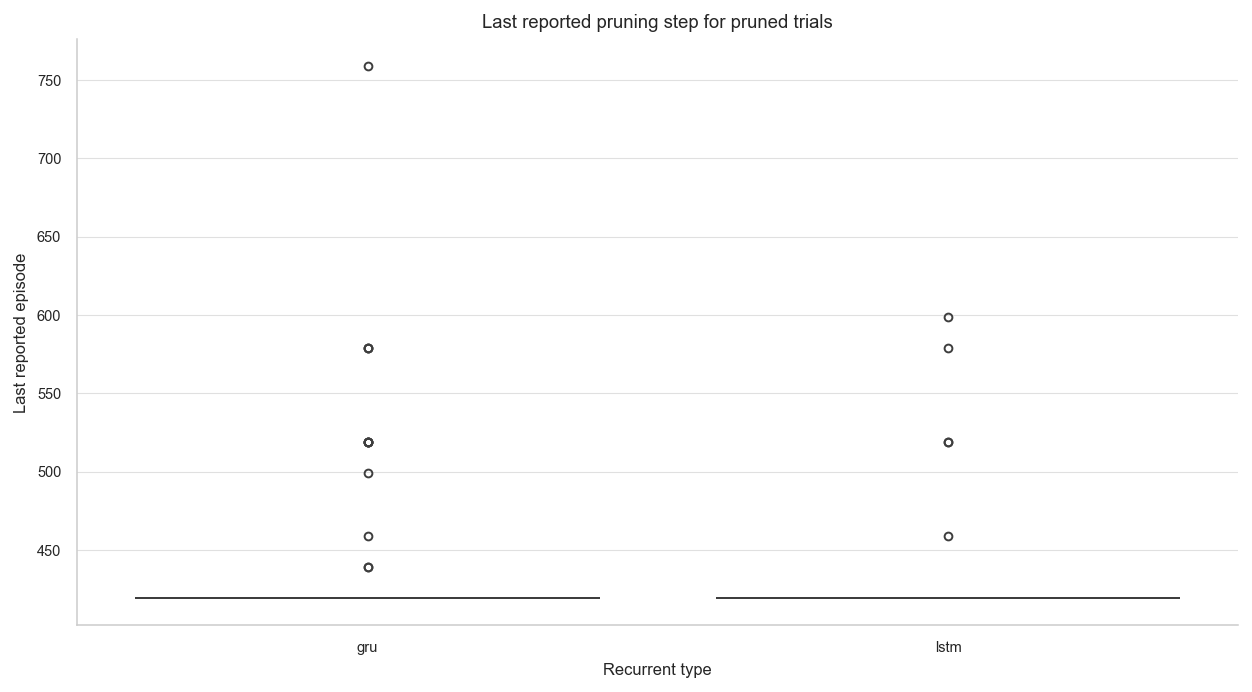

In [147]:
records = []
for tr in study.trials:
    rtype = tr.params.get('recurrent_type')
    if not tr.intermediate_values:
        records.append({
            'trial_number': tr.number,
            'recurrent_type': rtype,
            'state': tr.state.name,
            'step': np.nan,
            'intermediate_value': np.nan,
        })
        continue
    for step, value in sorted(tr.intermediate_values.items()):
        records.append({
            'trial_number': tr.number,
            'recurrent_type': rtype,
            'state': tr.state.name,
            'step': step,
            'intermediate_value': value,
        })

intermediate_df = pd.DataFrame(records)
display(intermediate_df.head())

prune_summary = df.groupby('params_recurrent_type')['state'].value_counts(normalize=True).rename('share').reset_index()
display(prune_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_df = intermediate_df.dropna(subset=['step', 'intermediate_value']).copy()
for rtype, sub in plot_df.groupby('recurrent_type'):
    for trial_id, trial_sub in sub.groupby('trial_number'):
        axes[0].plot(trial_sub['step'], trial_sub['intermediate_value'], alpha=0.08, color=('tab:blue' if rtype == 'gru' else 'tab:orange'))
    #med = sub.groupby('step')['intermediate_value'].median().reset_index()
    #axes[0].plot(med['step'], med['intermediate_value'], linewidth=2.5, label=f'{rtype} median')
axes[0].set_title('Intermediate pruning-score trajectories')
axes[0].set_xlabel('Training episode')
axes[0].set_ylabel('Reported pruning score')
#axes[0].legend()

prune_rate = pd.crosstab(df['params_recurrent_type'], df['state'], normalize='index')
prune_rate.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20c')
axes[1].set_title('State share by recurrent type')
axes[1].set_xlabel('Recurrent type')
axes[1].set_ylabel('Share of trials')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
save_fig('07_pruning_trajectories_and_state_share')
plt.show()

last_report = plot_df.groupby('trial_number')['step'].max().rename('last_report_step').reset_index()
trial_state_map = df[['number', 'state', 'params_recurrent_type']].rename(columns={'number': 'trial_number'})
prune_steps = last_report.merge(trial_state_map, on='trial_number', how='left')
plt.figure(figsize=(9, 5))
sns.boxplot(data=prune_steps[prune_steps['state'] == 'PRUNED'], x='params_recurrent_type', y='last_report_step')
plt.title('Last reported pruning step for pruned trials')
plt.xlabel('Recurrent type')
plt.ylabel('Last reported episode')
plt.tight_layout()
save_fig('07_pruning_trajectories_and_state_share')
plt.show()

## 4. W&B Run Analysis

The SQLite study is enough for trial-level search analysis, but not for the **training dynamics**. This section uses Weights & Biases to inspect how reward, entropy, and pruning scores evolved during training.

If the W&B project or entity name differs on your machine, edit the config cell at the top of the notebook before running these cells.

In [148]:
import wandb

api = wandb.Api(timeout=60)
runs = api.runs(f'{WANDB_ENTITY}/{WANDB_PROJECT}')


def summary_family(summary, prefix):
    out = {}
    pat = re.compile(rf'^{re.escape(prefix)}(\d+)$')
    for k, v in (summary or {}).items():
        if not isinstance(k, str):
            continue
        m = pat.match(k)
        if m:
            try:
                out[int(m.group(1))] = float(v)
            except Exception:
                pass
    return out

rows = []
for r in runs:
    summ = dict(r.summary or {})
    cfg = dict(r.config or {})
    search_space = cfg.get('search_space', {}) if isinstance(cfg, dict) else {}
    if 'recurrent_type' not in search_space:
        continue
    objective = summ.get('eval/weighted_avg')
    if objective is None:
        continue
    rows.append({
        'name': r.name,
        'run_id': r.id,
        'url': f'https://wandb.ai/{WANDB_ENTITY}/{WANDB_PROJECT}/runs/{r.id}',
        'recurrent_type': search_space.get('recurrent_type'),
        'recurrent_units': search_space.get('recurrent_units'),
        'objective': float(objective),
        'score_by_vol': summary_family(summ, 'eval/score@'),
        'speed_by_vol': summary_family(summ, 'eval/avg_speed@'),
        'queue_by_vol': summary_family(summ, 'eval/avg_queue_length@'),
        'wait_by_vol': summary_family(summ, 'eval/cumulative_wait@'),
        **{f'cfg_{k}': v for k, v in search_space.items() if isinstance(v, (int, float, str, bool)) or v is None}
    })

wandb_df = pd.DataFrame(rows)
if wandb_df.empty:
    print('No W&B runs matched the current project/config filter.')
    selected_runs = pd.DataFrame(columns=['name', 'run_id', 'recurrent_type', 'objective', 'recurrent_units', 'url'])
else:
    wandb_df = wandb_df.sort_values('objective', ascending=False).reset_index(drop=True)
    print('W&B runs loaded:', len(wandb_df))
    display(wandb_df[['name', 'run_id', 'recurrent_type', 'objective', 'url']].head(12))

    selected_runs = pd.concat([
        wandb_df.head(WANDB_TOP_PER_TYPE),
        wandb_df[wandb_df['recurrent_type'] == 'gru'].head(WANDB_TOP_PER_TYPE),
        wandb_df[wandb_df['recurrent_type'] == 'lstm'].head(WANDB_TOP_PER_TYPE),
    ]).drop_duplicates(subset=['run_id']).reset_index(drop=True)

    summary_csv = CSV_DIR / 'wandb_run_summary.csv'
    wandb_df.to_csv(summary_csv, index=False)
    print(f'Saved CSV: {summary_csv}')

    selected_csv = CSV_DIR / 'wandb_selected_runs_topk.csv'
    selected_runs.to_csv(selected_csv, index=False)
    print(f'Saved CSV: {selected_csv}')

    display(selected_runs[['name', 'recurrent_type', 'objective', 'recurrent_units', 'url']])


W&B runs loaded: 217


,name,run_id,recurrent_type,objective,url
0,trial-261-v0,91nz8axc,lstm,-4.474982,https://wandb.ai/jzapanag/TrafficSignalControl...
1,trial-346-v0,7gymxfz3,gru,-4.558593,https://wandb.ai/jzapanag/TrafficSignalControl...
2,trial-294-v0,vgs6czfs,gru,-4.652167,https://wandb.ai/jzapanag/TrafficSignalControl...
3,trial-255-v0,uacf59ed,gru,-4.732659,https://wandb.ai/jzapanag/TrafficSignalControl...
4,trial-351-v0,kjyrypyb,gru,-4.738474,https://wandb.ai/jzapanag/TrafficSignalControl...
5,trial-78-v0,lail8rcy,gru,-4.758847,https://wandb.ai/jzapanag/TrafficSignalControl...
6,trial-157-v0,cq3w5vhw,gru,-4.764449,https://wandb.ai/jzapanag/TrafficSignalControl...
7,trial-356-v0,lqzphu20,gru,-4.802472,https://wandb.ai/jzapanag/TrafficSignalControl...
8,trial-147-v0,cxwtdj4x,gru,-4.803802,https://wandb.ai/jzapanag/TrafficSignalControl...
9,trial-315-v0,21nf4kxj,gru,-4.807939,https://wandb.ai/jzapanag/TrafficSignalControl...


Saved CSV: Code\search_analysis_v3_outputs\csv\wandb_run_summary.csv
Saved CSV: Code\search_analysis_v3_outputs\csv\wandb_selected_runs_topk.csv


,name,recurrent_type,objective,recurrent_units,url
0,trial-261-v0,lstm,-4.474982,128,https://wandb.ai/jzapanag/TrafficSignalControl...
1,trial-346-v0,gru,-4.558593,256,https://wandb.ai/jzapanag/TrafficSignalControl...
2,trial-294-v0,gru,-4.652167,256,https://wandb.ai/jzapanag/TrafficSignalControl...
3,trial-255-v0,gru,-4.732659,128,https://wandb.ai/jzapanag/TrafficSignalControl...
4,trial-351-v0,gru,-4.738474,256,https://wandb.ai/jzapanag/TrafficSignalControl...
5,trial-78-v0,gru,-4.758847,96,https://wandb.ai/jzapanag/TrafficSignalControl...
6,trial-267-v0,lstm,-4.830677,64,https://wandb.ai/jzapanag/TrafficSignalControl...
7,trial-296-v0,lstm,-4.858248,256,https://wandb.ai/jzapanag/TrafficSignalControl...
8,trial-272-v0,lstm,-4.898857,128,https://wandb.ai/jzapanag/TrafficSignalControl...
9,trial-372-v0,lstm,-5.042360,256,https://wandb.ai/jzapanag/TrafficSignalControl...


In [149]:
HISTORY_KEYS = [
    'train/reward',
    'train/ema_reward',
    'train/entropy',
    'train/pruning_eval',
    'train/pruning_eval@1000',
    'train/pruning_eval@1300',
    'train/pruning_eval@1600',
]


def fetch_history(run_id, keys=HISTORY_KEYS, samples=50000):
    run = api.run(f'{WANDB_ENTITY}/{WANDB_PROJECT}/{run_id}')

    # Pull the full sampled history and filter locally. This is more reliable
    # than passing sparse metric keys directly to the API call.
    hist = run.history(samples=samples, pandas=True)
    if hist is None or len(hist) == 0:
        return pd.DataFrame(columns=['_step'] + list(keys) + ['run_id', 'name'])

    cols = [c for c in ['_step'] + list(keys) if c in hist.columns]
    out = hist[cols].copy()
    if '_step' not in out.columns:
        out['_step'] = np.arange(len(out))

    metric_cols = [c for c in keys if c in out.columns]
    if metric_cols:
        out = out.dropna(subset=metric_cols, how='all')

    out = out.sort_values('_step').drop_duplicates(subset=['_step'], keep='last').reset_index(drop=True)
    out['run_id'] = run_id
    out['name'] = run.name
    return out

history_frames = []
for run_id in selected_runs['run_id']:
    try:
        frame = fetch_history(run_id)
        print(f'{run_id}: rows={len(frame)} cols={[c for c in frame.columns if c not in ['run_id', 'name']][:12]}')
        if not frame.empty:
            history_frames.append(frame)
    except Exception as e:
        print(f'History fetch failed for {run_id}: {e}')

history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
print('History rows:', len(history_df))
if not history_df.empty:
    display(history_df.head())
else:
    print('No W&B history rows loaded.')


91nz8axc: rows=800 cols=['_step', 'train/reward', 'train/ema_reward', 'train/entropy', 'train/pruning_eval', 'train/pruning_eval@1000', 'train/pruning_eval@1300', 'train/pruning_eval@1600']
7gymxfz3: rows=800 cols=['_step', 'train/reward', 'train/ema_reward', 'train/entropy', 'train/pruning_eval', 'train/pruning_eval@1000', 'train/pruning_eval@1300', 'train/pruning_eval@1600']
vgs6czfs: rows=800 cols=['_step', 'train/reward', 'train/ema_reward', 'train/entropy', 'train/pruning_eval', 'train/pruning_eval@1000', 'train/pruning_eval@1300', 'train/pruning_eval@1600']
uacf59ed: rows=800 cols=['_step', 'train/reward', 'train/ema_reward', 'train/entropy', 'train/pruning_eval', 'train/pruning_eval@1000', 'train/pruning_eval@1300', 'train/pruning_eval@1600']
kjyrypyb: rows=800 cols=['_step', 'train/reward', 'train/ema_reward', 'train/entropy', 'train/pruning_eval', 'train/pruning_eval@1000', 'train/pruning_eval@1300', 'train/pruning_eval@1600']
lail8rcy: rows=800 cols=['_step', 'train/reward', 

,_step,train/reward,train/ema_reward,train/entropy,train/pruning_eval,train/pruning_eval@1000,train/pruning_eval@1300,train/pruning_eval@1600,run_id,name
0,0,-3.872852,-3.872852,32.854416,NaN,NaN,NaN,NaN,91nz8axc,trial-261-v0
1,1,-4.282877,-3.893353,32.522526,NaN,NaN,NaN,NaN,91nz8axc,trial-261-v0
2,2,-4.507797,-3.924076,32.025326,NaN,NaN,NaN,NaN,91nz8axc,trial-261-v0
3,3,-3.178231,-3.886783,32.076736,NaN,NaN,NaN,NaN,91nz8axc,trial-261-v0
4,4,-2.928522,-3.838870,31.848976,NaN,NaN,NaN,NaN,91nz8axc,trial-261-v0


Saved figure: Code\search_analysis_v3_outputs\figures\09_training_median_reward_entropy_pruning.png


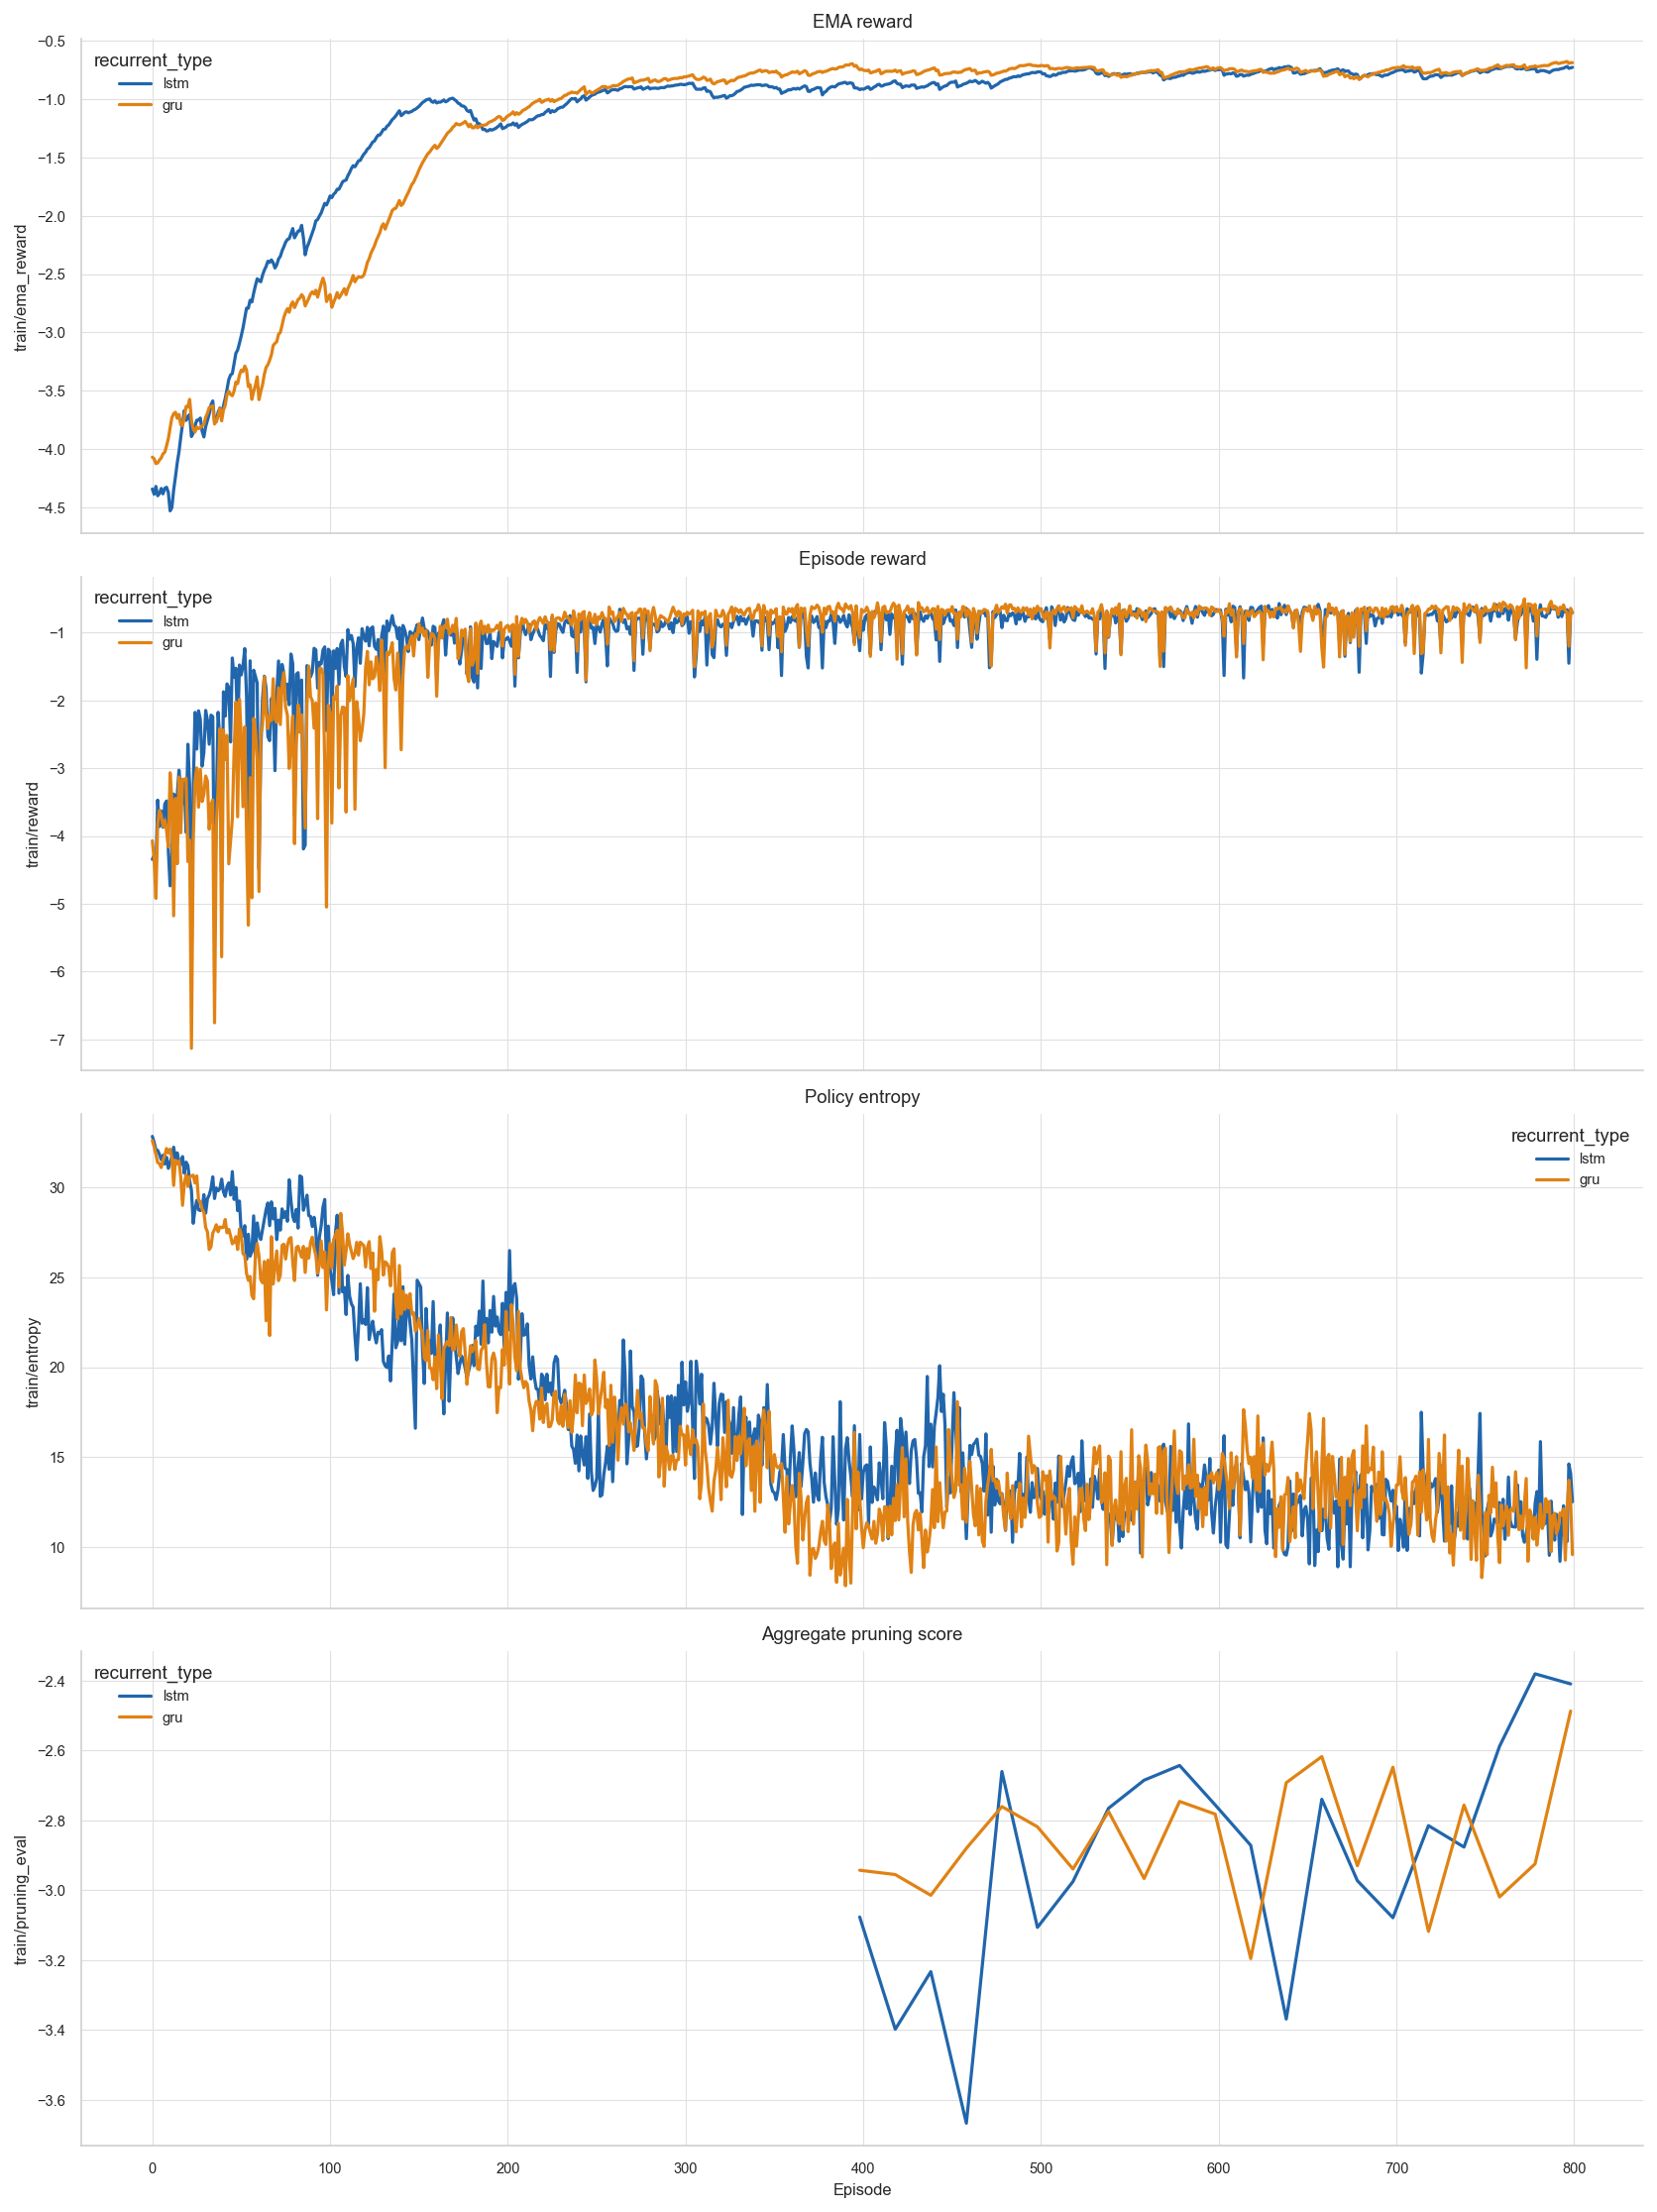

Saved figure: Code\search_analysis_v3_outputs\figures\10_pruning_metric_breakdown_by_demand.png


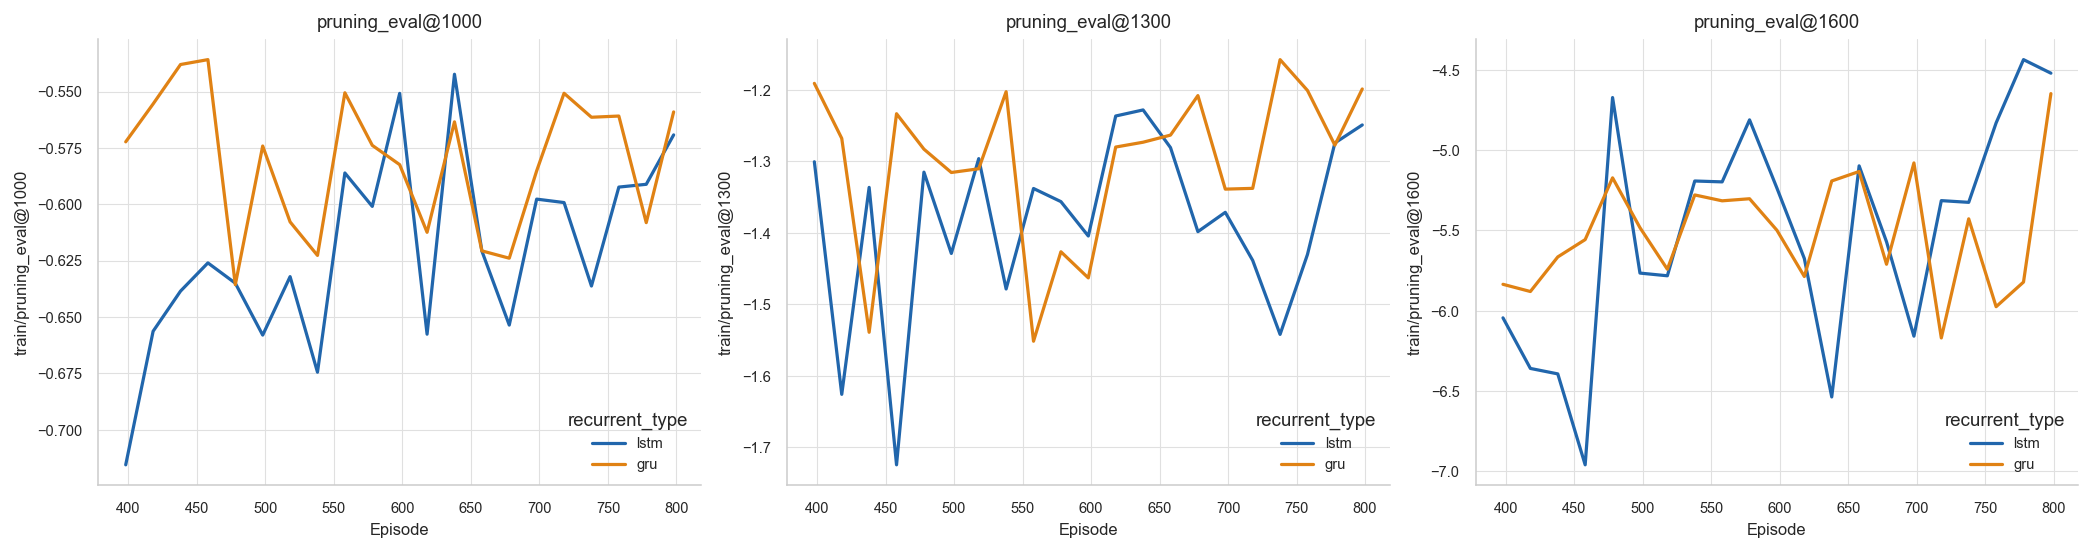

In [150]:
if history_df.empty:
    print('No W&B history rows loaded.')
else:
    plot_runs = selected_runs[['run_id', 'recurrent_type']].drop_duplicates()
    hist_plot = history_df.merge(plot_runs, on='run_id', how='left')

    metrics = [
        ('train/ema_reward', 'EMA reward'),
        ('train/reward', 'Episode reward'),
        ('train/entropy', 'Policy entropy'),
        ('train/pruning_eval', 'Aggregate pruning score'),
    ]
    fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 4 * len(metrics)), sharex=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, (metric, title) in zip(axes, metrics):
        if metric not in hist_plot.columns:
            ax.set_title(f'{title} (metric not present)')
            ax.set_xlabel('Episode')
            ax.set_ylabel(metric)
            continue
        sub = hist_plot.dropna(subset=[metric]).copy()
        if sub.empty:
            ax.set_title(f'{title} (no data)')
            ax.set_xlabel('Episode')
            ax.set_ylabel(metric)
            continue
        sns.lineplot(data=sub, x='_step', y=metric, hue='recurrent_type', estimator='median', errorbar=None, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Episode')
        ax.set_ylabel(metric)
    plt.tight_layout()
    save_fig('09_training_median_reward_entropy_pruning')
    plt.show()

    prune_metric_cols = [c for c in ['train/pruning_eval@1000', 'train/pruning_eval@1300', 'train/pruning_eval@1600'] if c in hist_plot.columns]
    prune_metric_cols = [c for c in prune_metric_cols if hist_plot[c].notna().any()]
    if prune_metric_cols:
        fig, axes = plt.subplots(1, len(prune_metric_cols), figsize=(5 * len(prune_metric_cols), 4), sharey=False)
        if len(prune_metric_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, prune_metric_cols):
            sub = hist_plot.dropna(subset=[col]).copy()
            sns.lineplot(data=sub, x='_step', y=col, hue='recurrent_type', estimator='median', errorbar=None, ax=ax)
            ax.set_title(col.replace('train/', ''))
            ax.set_xlabel('Episode')
        plt.tight_layout()
        save_fig('10_pruning_metric_breakdown_by_demand')
        plt.show()


### Training-Curve Detail Views

The median curves above summarize family-level behavior, but they can hide whether the pattern is consistent across the strongest runs or driven by a small number of outliers. The following plots complement the median view with:

- **top-5 individual curves per recurrent type**, ranked by final weighted objective
- **median + interquartile range** summaries for the two recurrent families

This is closer to the evaluation-style comparison already used later in the notebook: it exposes both the central trend and the behavior of the strongest individual configurations.


### Standalone Reward Summary Figure

This figure isolates the most presentation-ready training-dynamics view: the **median EMA reward** across episodes for each recurrent family, with the **interquartile range** shown as a shaded band. It is intended for direct use in slides or reports when only the reward-learning behavior needs to be highlighted.


Saved figure: Code\search_analysis_v3_outputs\figures\14a_standalone_median_iqr_ema_reward_by_recurrent_type.png


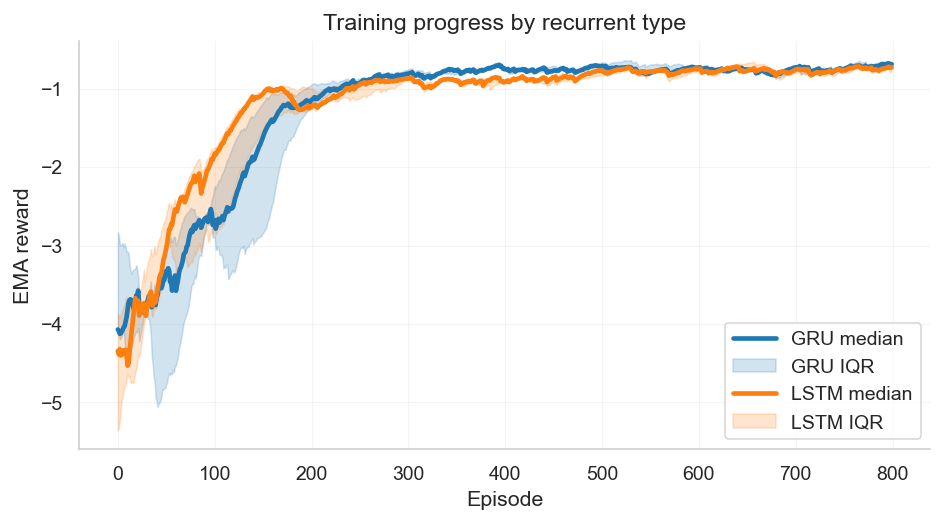

In [151]:
if history_df.empty:
    print('No W&B history rows loaded.')
else:
    reward_hist = history_df.merge(selected_runs[['run_id', 'recurrent_type']].drop_duplicates(), on='run_id', how='left')
    reward_hist = reward_hist.dropna(subset=['train/ema_reward', 'recurrent_type']).copy()

    if reward_hist.empty:
        print('No EMA reward history available for the standalone reward figure.')
    else:
        reward_summary = (
            reward_hist.groupby(['recurrent_type', '_step'])['train/ema_reward']
            .agg(q25=lambda x: np.nanpercentile(x, 25), median='median', q75=lambda x: np.nanpercentile(x, 75))
            .reset_index()
        )

        fig, ax = plt.subplots(figsize=(6.8, 3.8))

        palette = {'gru': 'tab:blue', 'lstm': 'tab:orange'}
        
        for rtype, rsub in reward_summary.groupby('recurrent_type'):
            rsub = rsub.sort_values('_step')
            color = palette.get(rtype, None)
        
            ax.plot(
                rsub['_step'],
                rsub['median'],
                linewidth=2.4,
                color=color,
                label=f'{rtype.upper()} median'
            )
        
            ax.fill_between(
                rsub['_step'],
                rsub['q25'],
                rsub['q75'],
                alpha=0.2,
                color=color,
                label=f'{rtype.upper()} IQR'
            )
        
        ax.set_title('Training progress by recurrent type', fontsize=12)
        ax.set_xlabel('Episode', fontsize=11)
        ax.set_ylabel('EMA reward', fontsize=11)
        ax.tick_params(axis='both', labelsize=10)
        ax.grid(True, alpha=0.35)
        
        ax.legend(
            fontsize=10,
            loc='lower right',
            frameon=True,
            ncol=1
        )
        
        fig.tight_layout()
        save_fig('14a_standalone_median_iqr_ema_reward_by_recurrent_type')
        plt.show()


Saved figure: Code\search_analysis_v3_outputs\figures\17_final_evaluation_grid_2x2.png


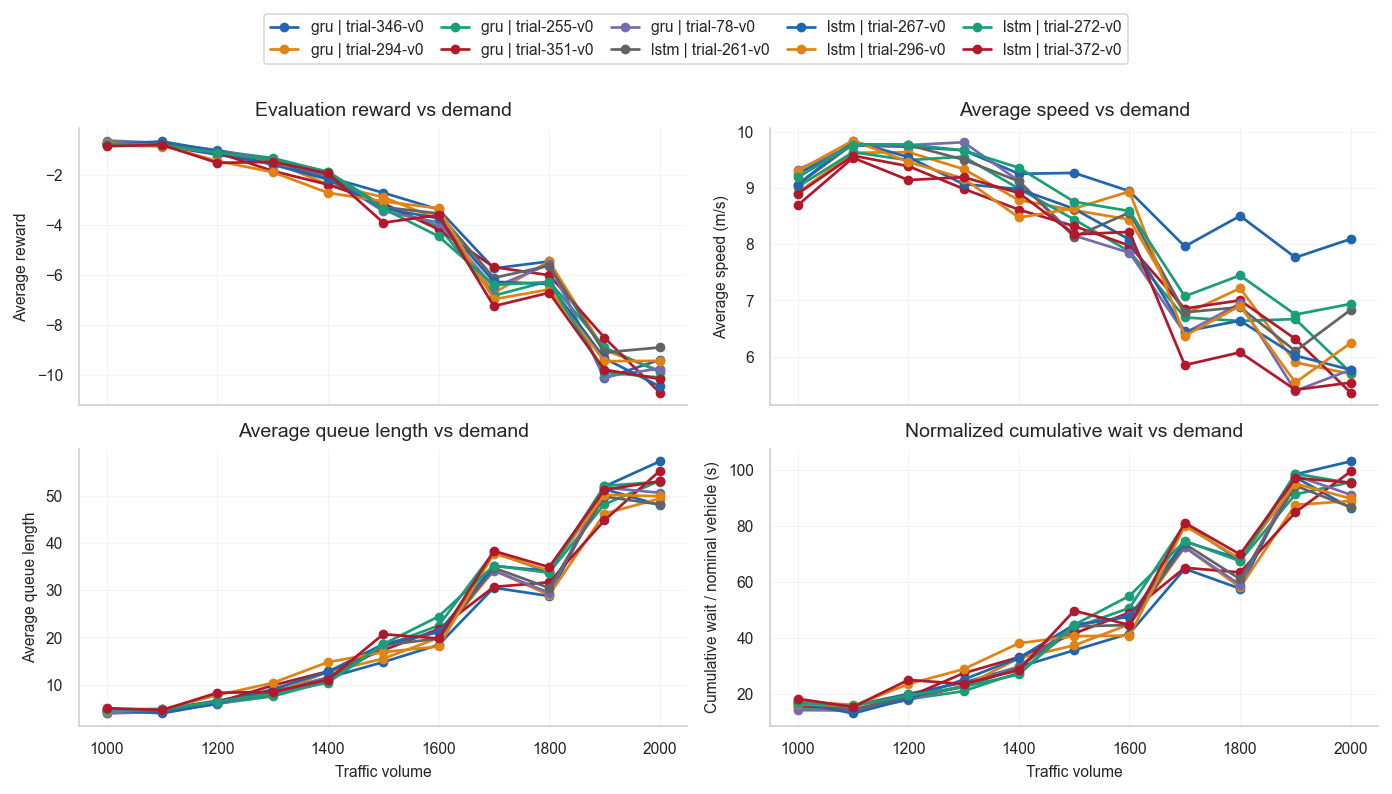

In [152]:
# Build this figure's inputs locally so it works in a clean, top-to-bottom run.
metric_specs = [
    ('score', 'Average reward', 'Evaluation reward vs demand'),
    ('speed', 'Average speed (m/s)', 'Average speed vs demand'),
    ('queue', 'Average queue length', 'Average queue length vs demand'),
    ('avg_wait_per_vehicle', 'Cumulative wait / nominal vehicle (s)', 'Normalized cumulative wait vs demand'),
]

grid_df = wandb_df.copy()
for dict_col, prefix in [
    ('score_by_vol', 'score'),
    ('speed_by_vol', 'speed'),
    ('queue_by_vol', 'queue'),
    ('wait_by_vol', 'wait'),
]:
    volumes_in_metric = sorted({
        volume
        for values in grid_df.get(dict_col, pd.Series(dtype=object))
        if isinstance(values, dict)
        for volume in values
    })
    for volume in volumes_in_metric:
        grid_df[f'{prefix}@{volume}'] = grid_df[dict_col].apply(
            lambda values, v=volume: values.get(v, np.nan) if isinstance(values, dict) else np.nan
        )

for volume in range(1000, 2100, 100):
    if f'wait@{volume}' in grid_df.columns:
        grid_df[f'avg_wait_per_vehicle@{volume}'] = grid_df[f'wait@{volume}'] / float(volume)

compare_df = pd.concat([
    grid_df[grid_df['recurrent_type'] == 'gru'].head(WANDB_TOP_PER_TYPE),
    grid_df[grid_df['recurrent_type'] == 'lstm'].head(WANDB_TOP_PER_TYPE),
]).reset_index(drop=True) if not grid_df.empty else grid_df

fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharex=True)
axes = axes.flatten()

for ax, (prefix, ylabel, title) in zip(axes, metric_specs):
    cols = [c for c in compare_df.columns if c.startswith(prefix + '@')]
    if not cols or compare_df.empty:
        ax.set_title(f'{title} (no data)', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=8)
        continue

    metric_vols = sorted(int(c.split('@')[1]) for c in cols)
    ordered = [f'{prefix}@{v}' for v in metric_vols]

    for _, row in compare_df.iterrows():
        label = f"{row['recurrent_type']} | {row['name']}"
        ax.plot(
            metric_vols,
            row[ordered].astype(float).values,
            marker='o',
            linewidth=1.4,
            markersize=4,
            label=label
        )

    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(True, alpha=0.35)

# Only bottom row needs x labels
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_xlabel("Traffic volume", fontsize=8)
axes[3].set_xlabel("Traffic volume", fontsize=8)

handles, labels = axes[0].get_legend_handles_labels()

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=5,
        fontsize=8,
        frameon=True,
        handlelength=1.8,
        columnspacing=1.1
    )

fig.tight_layout(rect=[0, 0, 1, 0.91])

save_fig('17_final_evaluation_grid_2x2')
plt.show()

Saved CSV: Code\search_analysis_v3_outputs\csv\wandb_final_evaluation_summary_wide.csv
Saved figure: Code\search_analysis_v3_outputs\figures\17_top_runs_score_vs_demand.png


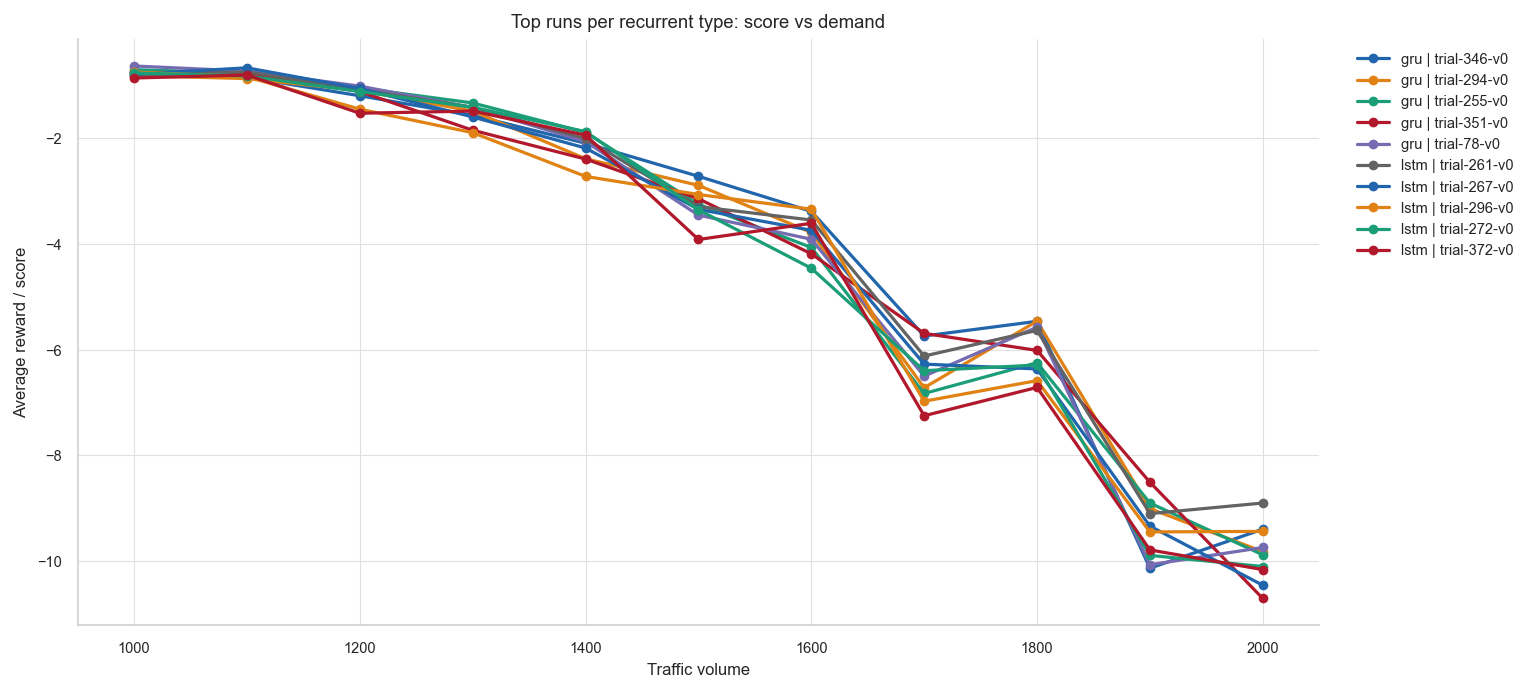

Saved figure: Code\search_analysis_v3_outputs\figures\18_top_runs_queue_vs_demand.png


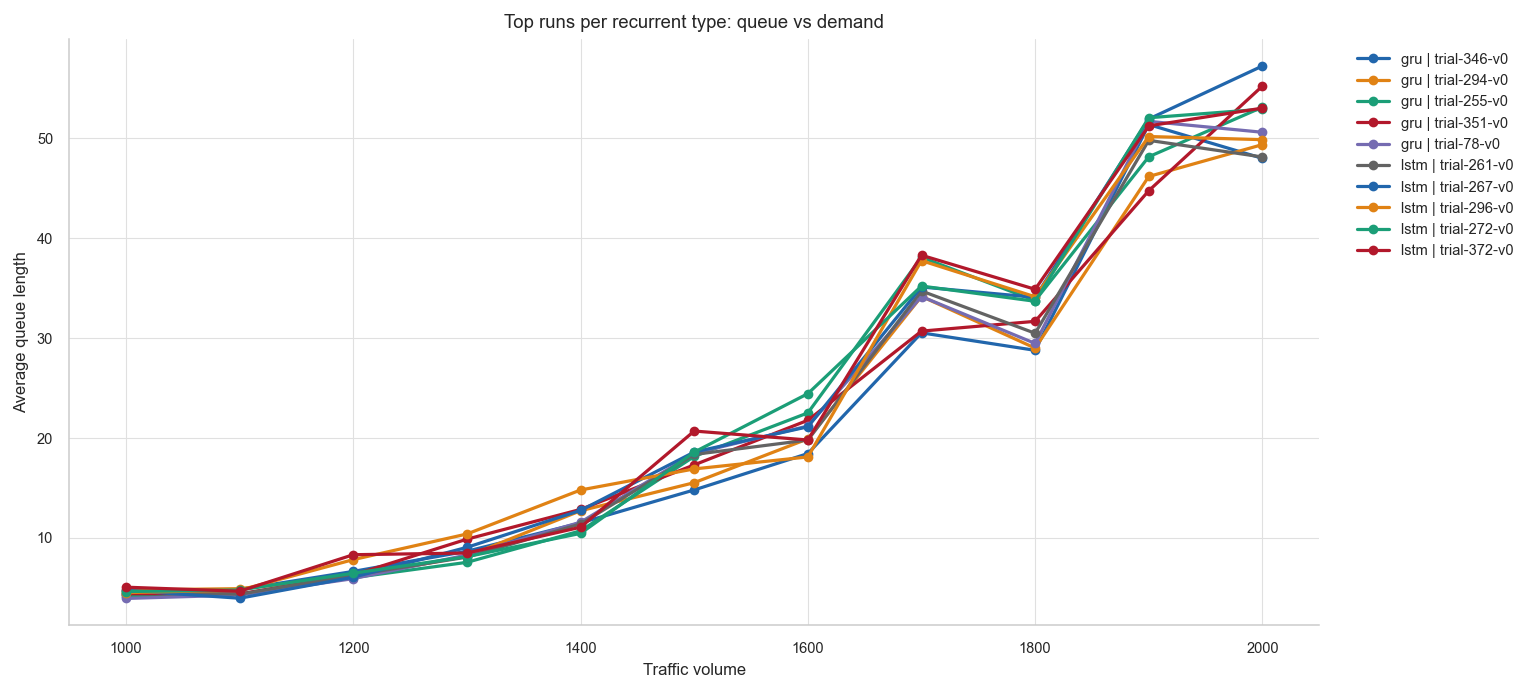

Saved figure: Code\search_analysis_v3_outputs\figures\19_top_runs_cumulative_wait_vs_demand.png


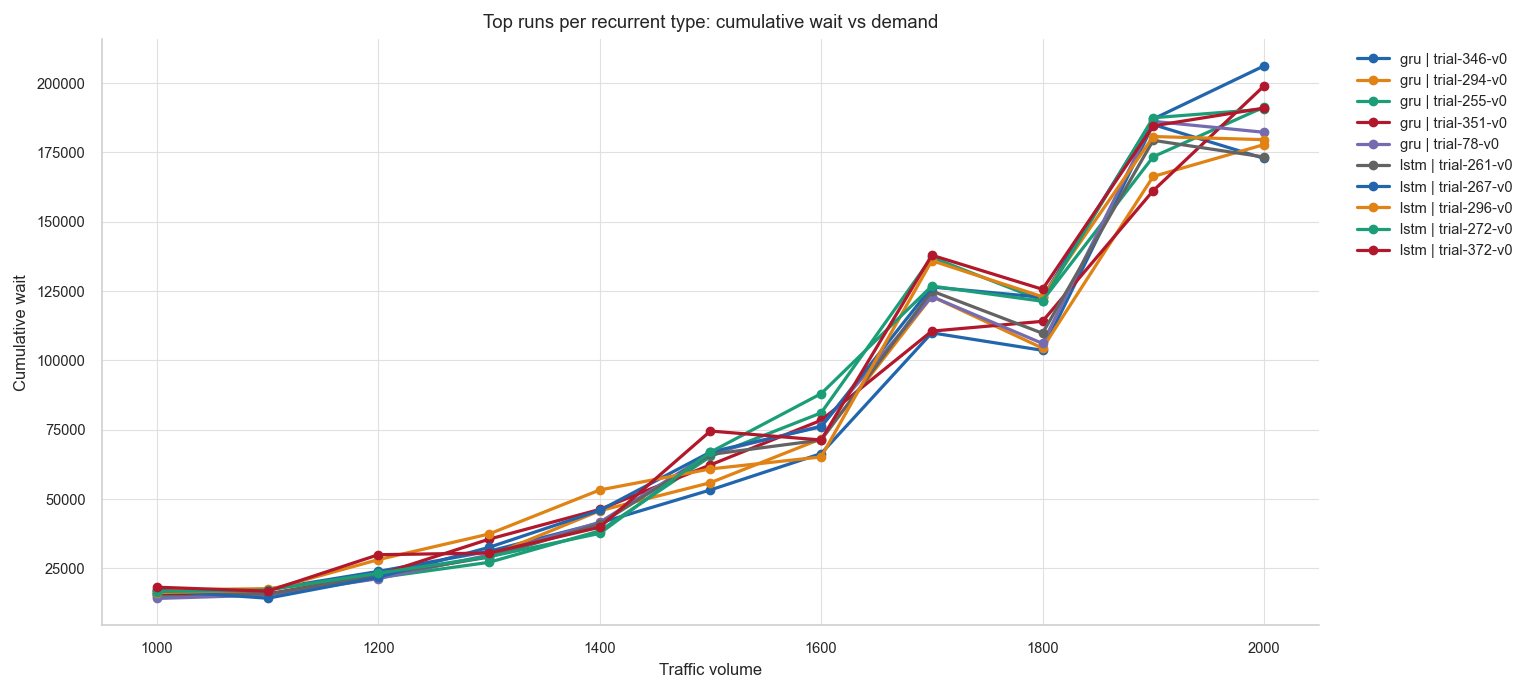

Saved figure: Code\search_analysis_v3_outputs\figures\20_top_runs_normalized_wait_vs_demand.png


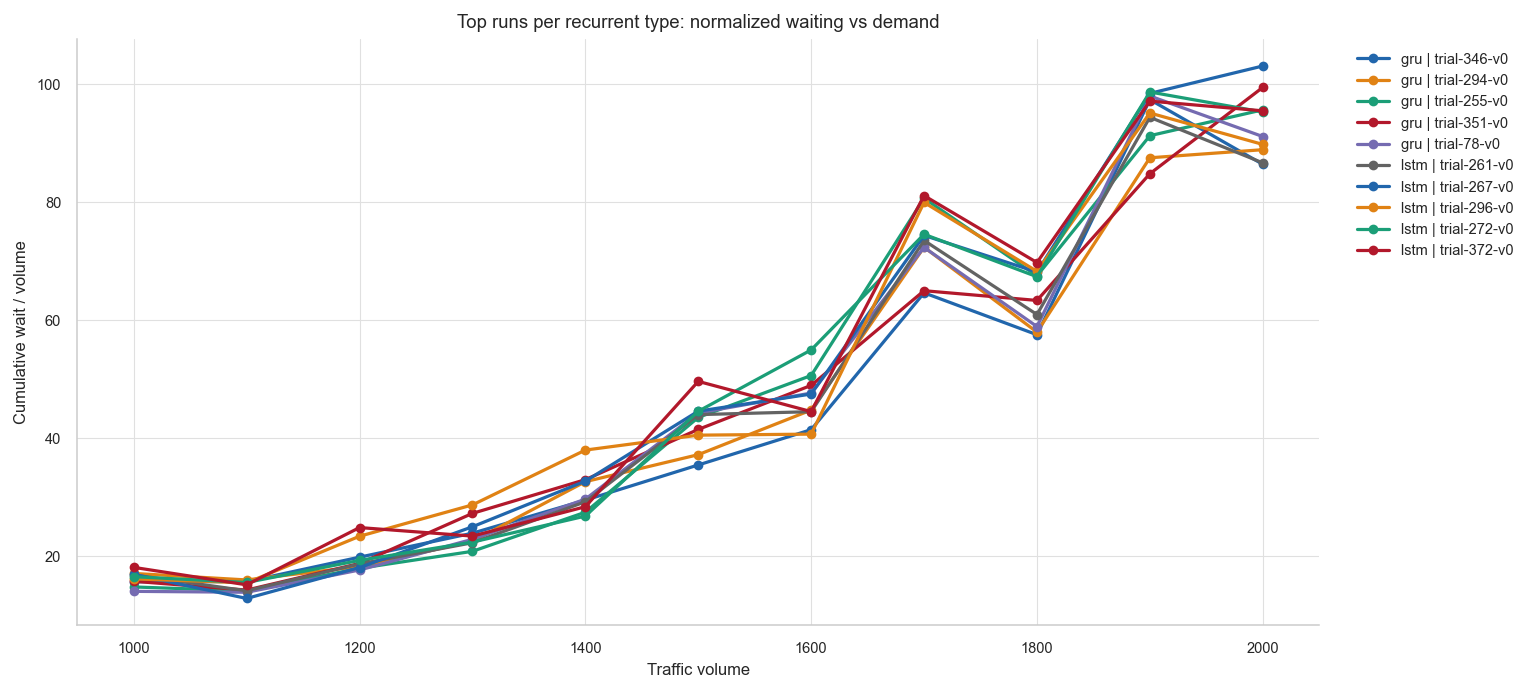

Saved figure: Code\search_analysis_v3_outputs\figures\21_top_runs_speed_vs_demand.png


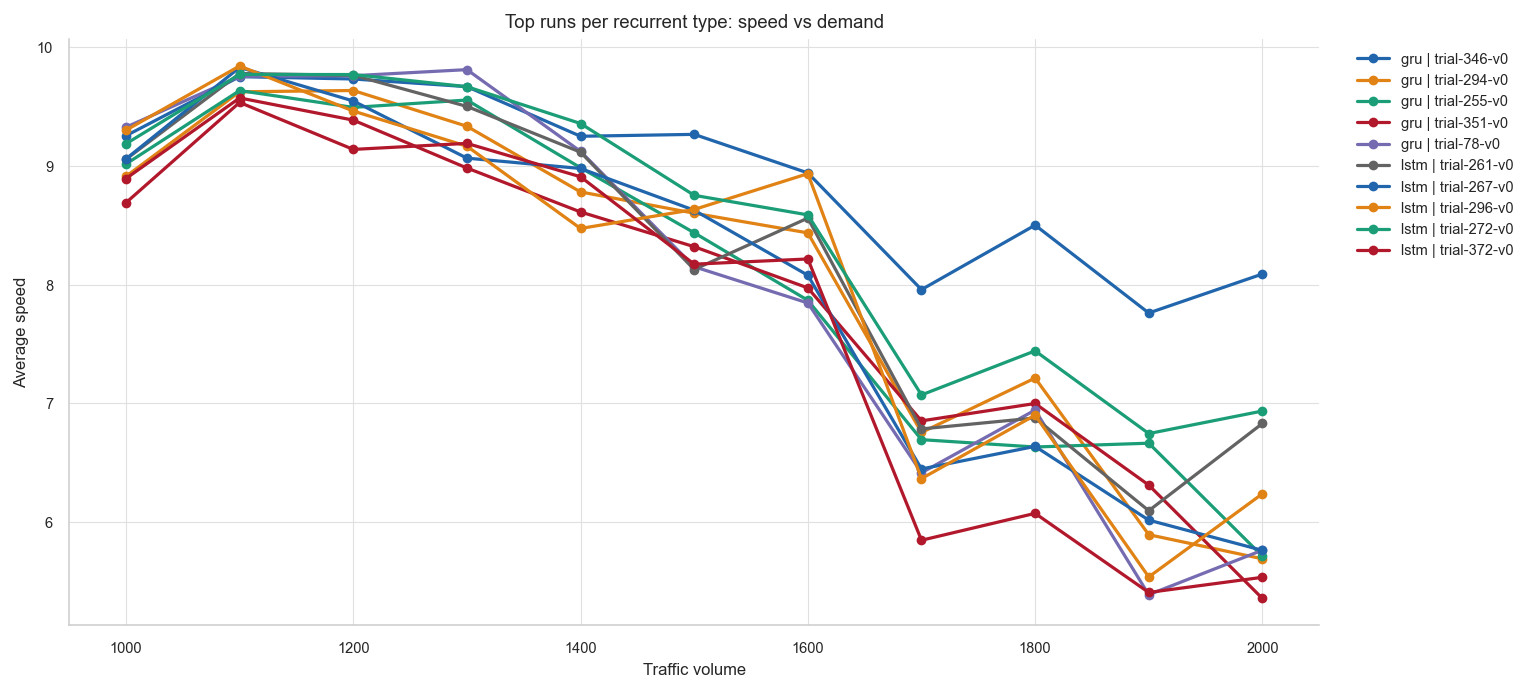

In [153]:
if wandb_df.empty:
    print('No W&B summary data available for family plots.')
else:
    def expand_metric(df_in, dict_col, prefix):
        all_vols = sorted(set(v for d in df_in[dict_col] for v in (d or {}).keys()))
        out = df_in.copy()
        for vol in all_vols:
            out[f'{prefix}@{vol}'] = out[dict_col].apply(lambda d: d.get(vol, np.nan) if isinstance(d, dict) else np.nan)
        return out, all_vols

    family_df, vols = expand_metric(wandb_df, 'score_by_vol', 'score')
    family_df, _ = expand_metric(family_df, 'speed_by_vol', 'speed')
    family_df, _ = expand_metric(family_df, 'queue_by_vol', 'queue')
    family_df, _ = expand_metric(family_df, 'wait_by_vol', 'wait')

    for vol in vols:
        if f'wait@{vol}' in family_df.columns:
            family_df[f'avg_wait_per_vehicle@{vol}'] = family_df[f'wait@{vol}'] / float(vol)

    final_eval_csv = CSV_DIR / 'wandb_final_evaluation_summary_wide.csv'
    family_df.to_csv(final_eval_csv, index=False)
    print(f'Saved CSV: {final_eval_csv}')

    compare_df = pd.concat([
        family_df[family_df['recurrent_type'] == 'gru'].head(WANDB_TOP_PER_TYPE),
        family_df[family_df['recurrent_type'] == 'lstm'].head(WANDB_TOP_PER_TYPE),
    ]).reset_index(drop=True)

    def plot_family(df_in, prefix, ylabel, title, filename):
        cols = [c for c in df_in.columns if c.startswith(prefix + '@')]
        if not cols or df_in.empty:
            print(f'No data for {title}.')
            return
        vols = sorted(int(c.split('@')[1]) for c in cols)
        ordered = [f'{prefix}@{v}' for v in vols]
        plt.figure(figsize=(11, 5))
        for _, row in df_in.iterrows():
            label = f"{row['recurrent_type']} | {row['name']}"
            plt.plot(vols, row[ordered].astype(float).values, marker='o', label=label)
        plt.title(title)
        plt.xlabel('Traffic volume')
        plt.ylabel(ylabel)
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        save_fig(filename)
        plt.show()

    plot_family(compare_df, 'score', 'Average reward / score', 'Top runs per recurrent type: score vs demand', '17_top_runs_score_vs_demand')
    plot_family(compare_df, 'queue', 'Average queue length', 'Top runs per recurrent type: queue vs demand', '18_top_runs_queue_vs_demand')
    plot_family(compare_df, 'wait', 'Cumulative wait', 'Top runs per recurrent type: cumulative wait vs demand', '19_top_runs_cumulative_wait_vs_demand')
    plot_family(compare_df, 'avg_wait_per_vehicle', 'Cumulative wait / volume', 'Top runs per recurrent type: normalized waiting vs demand', '20_top_runs_normalized_wait_vs_demand')
    plot_family(compare_df, 'speed', 'Average speed', 'Top runs per recurrent type: speed vs demand', '21_top_runs_speed_vs_demand')


### Optimized PPO controllers versus adaptive and untuned baselines

This comparison uses retained W&B evaluation records for optimized PPO-LSTM Trial 261 and PPO-GRU Trial 346, plus the raw 10-seed evaluation records for max-pressure and the a-priori CNN-LSTM PPO baseline. Exact optimized-controller episode rewards are recovered from the final evaluation blocks in each run's W&B console log and validated against the stored demand-wise score means. The waiting panel uses the historical notebook definition: per-demand cumulative waiting time divided by the nominal generated traffic volume.

In [154]:
import importlib
import sys
from pathlib import Path

comparison_start = Path.cwd().resolve()
comparison_repo_root = next(
    candidate for candidate in (comparison_start, *comparison_start.parents)
    if (candidate / 'Code').is_dir() and (candidate / 'results').is_dir()
)
comparison_code_dir = comparison_repo_root / 'Code'
if str(comparison_code_dir) not in sys.path:
    sys.path.insert(0, str(comparison_code_dir))

import controller_baseline_comparison as controller_comparison_module
controller_comparison_module = importlib.reload(controller_comparison_module)

from controller_baseline_comparison import (
    export_controller_comparison,
    load_controller_comparison,
)

controller_comparison_bundle = load_controller_comparison(comparison_repo_root)
controller_comparison_raw_df = controller_comparison_bundle['raw_df']
optimized_controller_means_df = controller_comparison_bundle['optimized_means_df']
optimized_reward_episodes_df = controller_comparison_bundle['optimized_reward_df']
controller_comparison_df = controller_comparison_bundle['comparison_df']
controller_comparison_table = controller_comparison_bundle['aggregate_table']

print('Comparison sources:')
for controller, source in controller_comparison_bundle['source_files'].items():
    print(f'  {controller}: {source}')
print(f'Raw baseline evaluation rows retained: {len(controller_comparison_raw_df)}')
print('Optimized uncertainty uses W&B histograms for traffic metrics and exact console-log episode rewards for reward.')

Comparison sources:
  Max-pressure: C:\Users\jazg2\OneDrive\Documents\IA368FF-RL\ProjetoComputacional\TrafficSignalControl_RL\results\max_pressure_20260827-114143\evaluation_episodes.csv
  PPO (A-priori): C:\Users\jazg2\OneDrive\Documents\IA368FF-RL\ProjetoComputacional\TrafficSignalControl_RL\results\ppo_default_20260827-114918\evaluation_episodes.csv
  optimized: C:\Users\jazg2\OneDrive\Documents\IA368FF-RL\ProjetoComputacional\TrafficSignalControl_RL\Code\Code\search_analysis_v3_outputs\csv\wandb_final_evaluation_summary_wide.csv
  optimized_histograms: C:\Users\jazg2\OneDrive\Documents\IA368FF-RL\ProjetoComputacional\TrafficSignalControl_RL\Code\search_analysis_v3_outputs\csv\optimized_wandb_histogram_summary.csv
Raw baseline evaluation rows retained: 220
Optimized means and uncertainty are loaded from the retained W&B evaluation summaries and histograms.


Saved figure: C:\Users\jazg2\OneDrive\Documents\IA368FF-RL\ProjetoComputacional\TrafficSignalControl_RL\Code\search_analysis_v3_outputs\figures\18_controller_baseline_comparison_with_insets.png
Saved demand summary: C:\Users\jazg2\OneDrive\Documents\IA368FF-RL\ProjetoComputacional\TrafficSignalControl_RL\Code\search_analysis_v3_outputs\csv\controller_baseline_comparison_demand_summary.csv


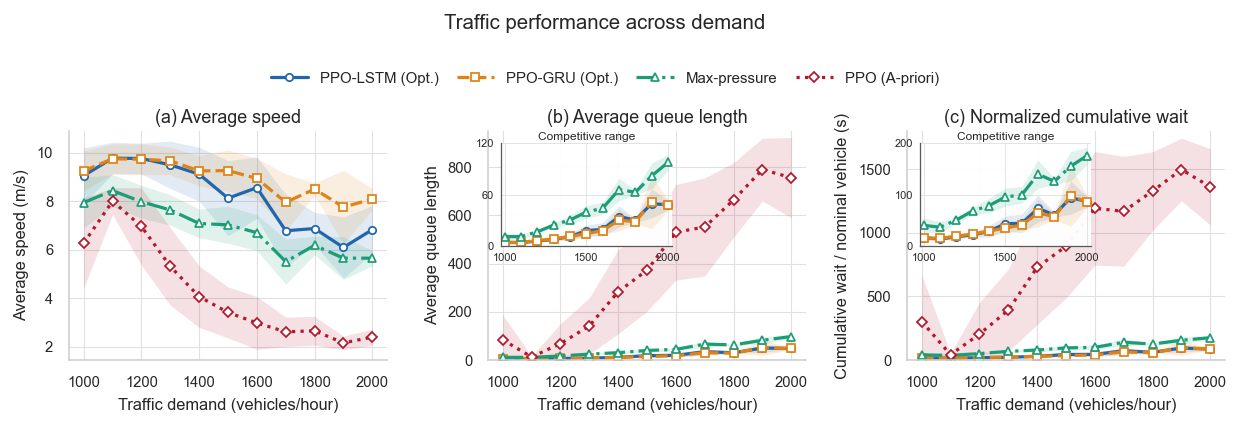

In [155]:
controller_comparison_paths = export_controller_comparison(controller_comparison_bundle)
print(f"Existing 1x4 figure: {controller_comparison_paths['figure_1x4']}")
print(f"Existing 2x2 figure: {controller_comparison_paths['figure_2x2']}")
print(f"Saved corrected 2x2 figure: {controller_comparison_paths['figure_2x2_corrected']}")
print(f"Saved demand summary: {controller_comparison_paths['demand_summary']}")
plt.show()

In [156]:
controller_comparison_table.style.format({
    'Weighted objective': '{:.3f}',
    'Mean queue': '{:.3f}',
    'Mean speed (m/s)': '{:.3f}',
    'Normalized cumulative wait (s/nominal vehicle)': '{:.3f}',
})

,Controller,Weighted objective,Mean queue,Mean speed (m/s),Normalized cumulative wait (s/nominal vehicle)
0,PPO-LSTM (Opt.),-4.475,21.448,8.228,45.933
1,PPO-GRU (Opt.),-4.559,20.708,8.926,44.325
2,Max-pressure,-8.651,44.361,6.895,97.162
3,PPO (A-priori),-99.549,386.437,4.262,827.548


**Full-width 1x4 candidate**

![Four-metric controller comparison in a 1x4 layout](search_analysis_v3_outputs/figures/18_controller_comparison_1x4.png)

**Compact 2x2 fallback**

![Four-metric controller comparison in a 2x2 layout](search_analysis_v3_outputs/figures/18_controller_comparison_2x2.png)

**Corrected 2x2 layout (paper candidate)**

![Corrected four-metric controller comparison](search_analysis_v3_outputs/figures/18_controller_comparison_2x2_corrected.png)

**Suggested caption.** Demand-wise comparison of the optimized PPO configurations and baseline controllers. Curves represent mean performance across ten matched traffic realizations per demand level, with shaded regions indicating traffic-realization variability. Insets provide an expanded view of the competitive range where the substantially poorer a-priori PPO compresses the main-axis scale.

Saved CSV: Code\search_analysis_v3_outputs\csv\wandb_robustness_summary.csv


,name,run_id,recurrent_type,objective,score_mean,score_std,score_min,score_max,score_range,score_slope
0,trial-261-v0,91nz8axc,lstm,-4.474982,-3.878358,2.979016,-9.100215,-0.743734,8.356480,-0.008949
1,trial-346-v0,7gymxfz3,gru,-4.558593,-3.935572,3.187394,-10.132269,-0.748126,9.384144,-0.009345
2,trial-294-v0,vgs6czfs,gru,-4.652167,-4.030989,3.118385,-9.819923,-0.816525,9.003398,-0.009318
3,trial-255-v0,uacf59ed,gru,-4.732659,-4.083220,3.214845,-9.879185,-0.703635,9.175550,-0.009742
4,trial-351-v0,kjyrypyb,gru,-4.738474,-4.102970,3.152324,-10.704817,-0.757514,9.947303,-0.009533
5,trial-78-v0,lail8rcy,gru,-4.758847,-4.100885,3.303223,-10.067411,-0.633930,9.433480,-0.009869
6,trial-157-v0,cq3w5vhw,gru,-4.764449,-4.103317,3.324258,-11.063202,-0.750771,10.312431,-0.009917
7,trial-356-v0,lqzphu20,gru,-4.802472,-4.128817,3.369183,-9.758076,-0.685352,9.072724,-0.010105
8,trial-147-v0,cxwtdj4x,gru,-4.803802,-4.115599,3.494242,-10.625916,-0.654342,9.971574,-0.010323
9,trial-315-v0,21nf4kxj,gru,-4.807939,-4.125183,3.432384,-10.486644,-0.695668,9.790976,-0.010241


Saved figure: Code\search_analysis_v3_outputs\figures\22_robustness_scatter_plots.png


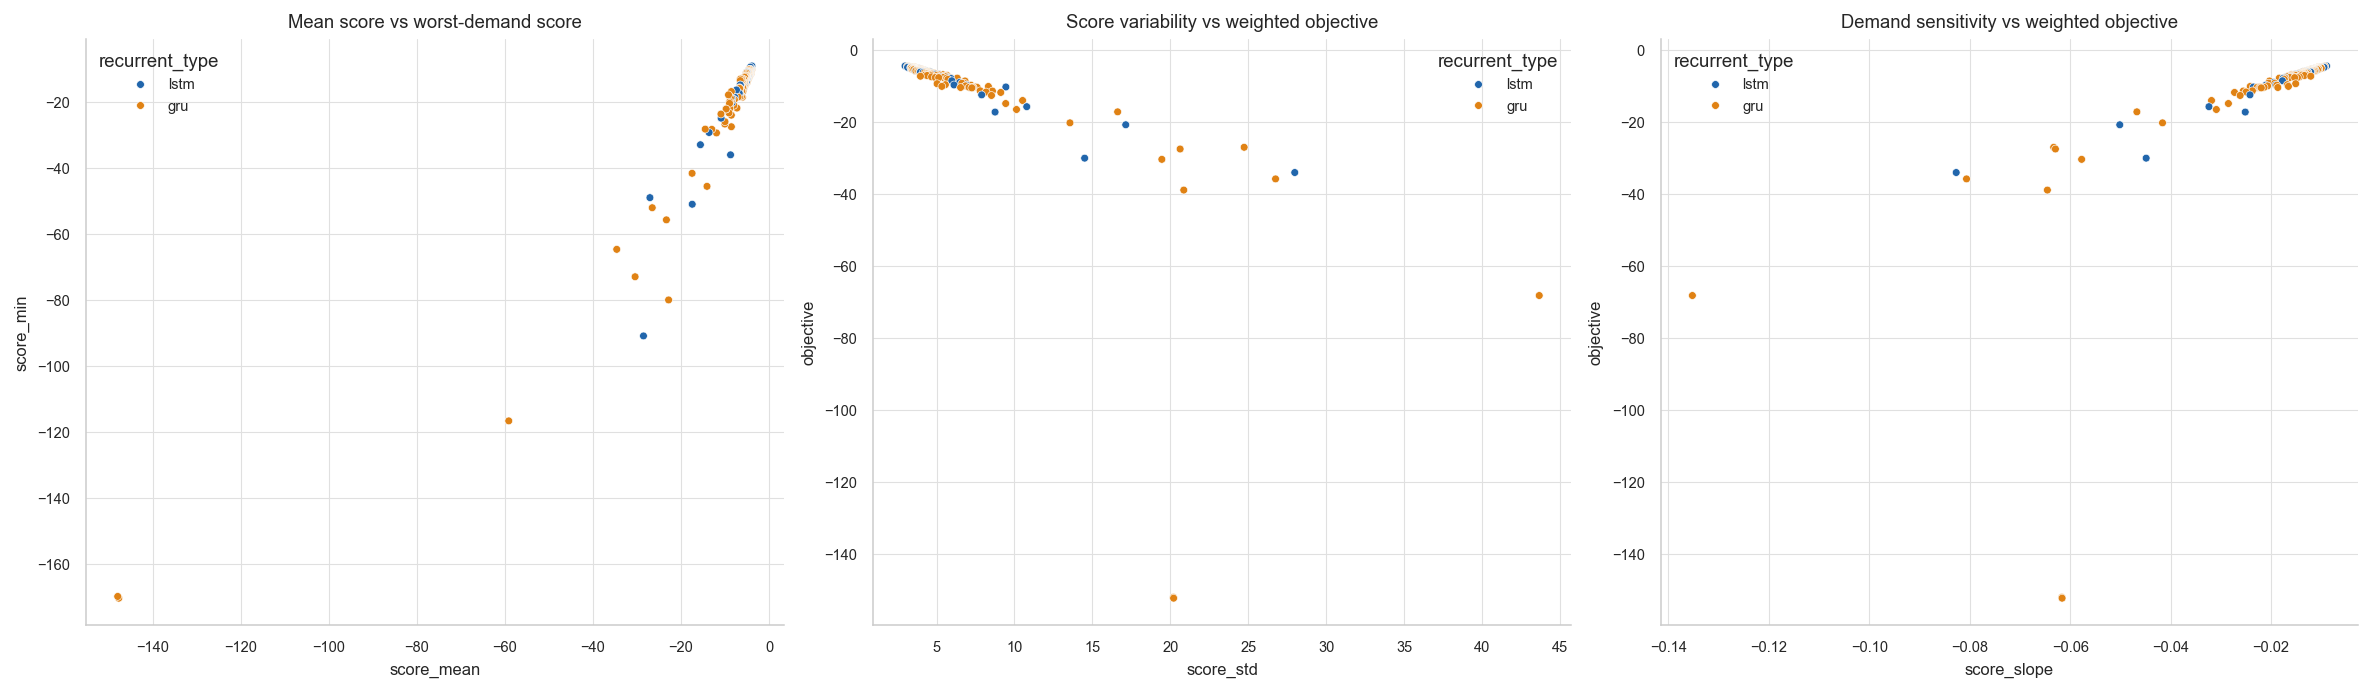

In [157]:
if wandb_df.empty:
    print('No W&B summary data available for robustness plots.')
else:
    def robustness_features(row):
        vols = sorted(row['score_by_vol'].keys())
        scores = np.array([row['score_by_vol'][v] for v in vols], dtype=float)
        x = np.array(vols, dtype=float)
        slope = np.polyfit(x, scores, 1)[0] if len(scores) >= 2 else np.nan
        return pd.Series({
            'score_mean': scores.mean(),
            'score_std': scores.std(),
            'score_min': scores.min(),
            'score_max': scores.max(),
            'score_range': scores.max() - scores.min(),
            'score_slope': slope,
        })

    robust_df = pd.concat([wandb_df[['name', 'run_id', 'recurrent_type', 'objective']], wandb_df.apply(robustness_features, axis=1)], axis=1)
    robustness_csv = CSV_DIR / 'wandb_robustness_summary.csv'
    robust_df.to_csv(robustness_csv, index=False)
    print(f'Saved CSV: {robustness_csv}')
    display(robust_df.sort_values('objective', ascending=False).head(12))

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    sns.scatterplot(data=robust_df, x='score_mean', y='score_min', hue='recurrent_type', ax=axes[0])
    axes[0].set_title('Mean score vs worst-demand score')

    sns.scatterplot(data=robust_df, x='score_std', y='objective', hue='recurrent_type', ax=axes[1])
    axes[1].set_title('Score variability vs weighted objective')

    sns.scatterplot(data=robust_df, x='score_slope', y='objective', hue='recurrent_type', ax=axes[2])
    axes[2].set_title('Demand sensitivity vs weighted objective')

    plt.tight_layout()
    save_fig('22_robustness_scatter_plots')
    plt.show()


## 5. What to Look For in the Results

The most useful conclusions from this notebook are usually not just the single best trial. The higher-value questions are:

- Does one recurrent family dominate **globally**, or do GRU and LSTM prefer **different architectural regimes**?
- Is one family being **pruned earlier** even when its late-stage completed trials are competitive?
- Do the top GRU and top LSTM runs differ in **entropy decay** or **reward stabilization** during training?
- Are there architectural choices that improve the final weighted score but worsen the **worst-demand** behavior?
- Do top trials succeed because they are better **on average**, or because they are more **robust across demand levels**?

## Suggested next analysis steps

1. Build separate Optuna importance analyses for GRU-only and LSTM-only follow-up studies if one family appears underexplored.
2. Compare the **top completed** and **top pruned** trials near the pruning threshold to see whether the current pruning rule is still too aggressive.
3. Add parameter-count estimates if you want a fairer efficiency comparison between GRU and LSTM at the same `recurrent_units`.
4. If one family remains underrepresented among completed trials, consider a balanced follow-up search with fixed recurrent type per study.